In [57]:
import pandas as pd
%reload_ext autoreload
%autoreload 2
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import Affine2D
from mpl_toolkits.axisartist.parasite_axes import HostAxes
import ipywidgets as widgets
from IPython.display import display, clear_output
from ipywidgets import interact, interactive
from tqdm.notebook import tqdm
from uncertainty_estimation import data_utils, glen_funcs, uncertainty_funcs, elias_funcs
import itertools
import multiprocess as mp
from functools import partial

In [58]:
# # list1 = ['BlueTopo_US5NH1AH_20220505.tiff', "Rough_FL.tif", "Rough_Slopey.tif", "Flat_LA.tif", "Slopey_MA.tif"]
# # list1 = ["Slopy.tif",'Rough.tif', 'Rocky.tif','Flat_TX.tif']
# list1 = ["Slopy.tif"]
# # list1 = ["Rocky.tif"]
# # list1 = ["Rough.tif"]
# # list1 = ['Flat_TX.tif']
# # window_multiples = [1, 2, 3, 4]
# window_multiples = [1]
# linespacing_meters = [32, 64, 128, 256, 512, 1024]
# # linespacing_meters =  [32,64]
# fxn_list = [elias_funcs.compute_fft_uncertainty,elias_funcs.compute_fft_uncertainty,elias_funcs.compute_fft_uncertainty,
#             elias_funcs.compute_fft_uncertainty,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,
#             elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,
#             elias_funcs.get_difference_uncertainties_max]
# fxn_methods = ['amplitude', 'psd_n', 'psd_lf', 'psd_df', 'diff', 'diff', 'diff', 'gaussian', 'gaussian', 'gaussian']
# fxn_names = ['amplitude', 'psd_n', 'psd_lf', 'psd_df', 'diff_max', 'diff_envelope1', 'diff_envelope3', 'gaussian_95', 'gaussian_99', 'gaussian_mean' ]
# if_fft_list = [True, True, True, True, False, False, False, False, False, False]
#
# method_list = list(zip(fxn_list, fxn_methods, fxn_names, if_fft_list))
#
# settings_list = list(itertools.product(list1, linespacing_meters, window_multiples, method_list))
# len(settings_list)
#
# # export
# outdir = r'C:/Users/eadediran/OneDrive - USNH/Documents/PhD/Results/uncertainty_methods_comparison/slopy/'
# seabed = 'slopy'
# path = f'{outdir}/{seabed}_uncertainty_comparison_results.csv'


In [59]:
# # working version with the right methods
# # list1 = ['BlueTopo_US5NH1AH_20220505.tiff', "Rough_FL.tif", "Rough_Slopey.tif", "Flat_LA.tif", "Slopey_MA.tif"]
# # list1 = ['isle.tiff']
# # list1 = ['sample_tiff2.tif']
# # list1 = ["Slopy.tif"]
# # list1 = ["Rough.tif"]
# # list1 = ["Rocky.tif"]
# # list1 = ['Flat_TX.tif']
# list1 = ['Flat_LA.tif']
# # window_multiples = [1, 2, 3, 4]
# window_multiples = [1]
# linespacing_meters = [32, 64, 128, 256, 512, 1024]
# if list1 == ["Rocky.tif"]:
#     linespacing_meters = [32, 64, 128, 256, 512]
# # linespacing_meters =  [32, 128]
# # fxn_list = [uncertainty_funcs.compute_amp_uncertainty, uncertainty_funcs.compute_psd_uncertainty,
# #             elias_funcs.compute_fft_uncertainty,elias_funcs.compute_fft_uncertainty,elias_funcs.compute_fft_uncertainty,
# #             elias_funcs.compute_fft_uncertainty,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,
# #             elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,
# #             elias_funcs.get_difference_uncertainties_max]
# # fxn_methods = ['amplitude', 'psd', 'amplitude', 'psd_n', 'psd_lf', 'psd_df', 'diff', 'diff', 'diff', 'diff', 'gaussian', 'gaussian']
# # fxn_names = ['Amplitude(F)', 'PSD(F)', 'amplitude', 'psd_n', 'psd_lf', 'psd_df', 'diff_max', 'diff_mean', 'diff_envelope1', 'diff_envelope3', 'gaussian_95', 'gaussian_99']
# # if_fft_list = [True, True, True, True, True, True, False, False, False, False, False, False]
# fxn_list = [elias_funcs.compute_fft_uncertainty,elias_funcs.compute_fft_uncertainty,elias_funcs.compute_fft_uncertainty,
#             elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,]
# fxn_methods = ['psd_n', 'psd_df', 'psd_lf', 'diff', 'diff', 'diff']
# fxn_names = ['psd_n', 'psd_df', 'psd_lf', 'diff_max', 'diff_mean', 'diff_envelope1']
# if_fft_list = [ True, True, True, False, False, False]
#
# # sampling_methods = ['both','right','left'] #use same if the sampling is same location
# sampling_methods = ['same']
# method_list = list(zip(fxn_list, fxn_methods, fxn_names, if_fft_list))
#
# settings_list = list(itertools.product(list1, linespacing_meters, window_multiples, method_list, sampling_methods))
# len(settings_list)
#
# # export
# # outdir = r'C:/Users/eadediran/OneDrive - USNH/Documents/PhD/Results/uncertainty_methods_comparison/orthogonal/both_filled/final/'
# outdir = r'C:/Users/eadediran/OneDrive - USNH/Documents/PhD/Results/uncertainty_methods_comparison/same/final/'
# seabed = 'flat1'

In [60]:
def create_list(mean, multiplier, res):
    div = np.floor(mean/res)
    mean = div*res
    result = np.linspace(mean, mean*multiplier, multiplier)
    return result[1:]

In [61]:
linespacing_meters_new = create_list(mean=63, multiplier=6, res=8)
linespacing_meters_new

array([112., 168., 224., 280., 336.])

In [62]:
linespacing_meters_original = [80, 128, 256, 512, 1024]
linespacing_meters = np.unique(np.sort(np.concatenate((linespacing_meters_original, linespacing_meters_new))))
linespacing_meters = linespacing_meters[linespacing_meters>=80]
linespacing_meters

array([  80.,  112.,  128.,  168.,  224.,  256.,  280.,  336.,  512.,
       1024.])

In [63]:
# test version
# list1 = ['BlueTopo_US5NH1AH_20220505.tiff', "Rough_FL.tif", "Rough_Slopey.tif", "Flat_LA.tif", "Slopey_MA.tif"]
# list1 = ['isle.tiff'] #80 #4
list1 = ['Rough_Slopy.tif'] #63
# list1 = ['Rough_Slopy_NNeighbor.tif'] #58
# list1 = ['Rough_Slopy_FNeighbor.tif'] #103
# list1 = ["Slopy.tif"] #121
# list1 = ["Slopy_FNeighbor.tif"] #47
# list1 = ["Slopy_SNeighbor.tif"] #126
# list1 = ["Rough.tif"] #23
# list1 = ["Rough_NNeighbor.tif"] #24
# list1 = ["Rough_SNeighbor.tif"]
# list1 = ["Rough_FNeighbor.tif"] #19
# list1 = ["Rocky.tif"] #58 #4
# list1 = ['Flat_TX.tif'] #32
# list1 = ['Flat_LA.tif'] #flat1 #42
# list1 = ['Flat_LA_NNeighbor.tif'] #24
# list1 = ['Flat_LA_SNeighbor.tif'] # 56
# window_multiples = [1, 2, 3, 4]

# list1 = {'Rough.tif','Rough_NNeighbor.tif','Rough_FNeighbor.tif','Slopy.tif','Slopy_FNeighbor.tif','Slopy_SNeighbor.tif','Rough_Slopy.tif','Rough_Slopy_FNeighbor.tif',
#             'Rough_Slopy_NNeighbor.tif','Rocky.tif', 'Isle.tiff'}
# list1 = ['Flat_TX.tif', 'Flat_LA.tif', 'Flat_LA_SNeighbor.tif','Flat_LA_NNeighbor.tif'] #combined_flat
# list1 = ['Flat_LA.tif', 'Flat_LA_SNeighbor.tif','Flat_LA_NNeighbor.tif'] #combined_flat1
#
# list1 = {'Rough.tif','Rough_NNeighbor.tif','Rough_FNeighbor.tif','Slopy.tif','Slopy_FNeighbor.tif','Slopy_SNeighbor.tif','Rough_Slopy.tif','Rough_Slopy_FNeighbor.tif','Rough_Slopy_NNeighbor.tif','Rocky.tif', 'Isle.tiff','Flat_TX.tif', 'Flat_LA.tif', 'Flat_LA_SNeighbor.tif','Flat_LA_NNeighbor.tif'}
# list1 = ['Flat_TX.tif', 'Flat_LA.tif']
# list1 = ['Flat_LA_SNeighbor.tif']
# list1 = ['Flat_LA_NNeighbor.tif']
window_multiples = [1]
# linespacing_meters = [32, 64, 128, 256, 512, 1024]
# linespacing_meters = [80, 128, 256, 512, 1024]

# linespacing_meters = np.linspace(32,160,5).tolist()
# linespacing_meters = [40, 72, 136, 264, 520, 1032]
# # linespacing_meters = [64, 256, 1024]
# if list1 == ["Slopy_SNeighbor.tif"]:
#     linespacing_meters = [32, 64, 128, 256, 512]
# if list1 == ["Slopy_FNeighbor.tif"]:
#     linespacing_meters = [32, 64, 128, 256, 512]
# if list1 == ["Rocky.tif"]:
#     linespacing_meters = [32, 64, 128, 256, 512, 1024]
# fxn_list = [uncertainty_funcs.compute_amp_uncertainty, uncertainty_funcs.compute_psd_uncertainty,
#             elias_funcs.compute_fft_uncertainty,elias_funcs.compute_fft_uncertainty,elias_funcs.compute_fft_uncertainty,
#             elias_funcs.compute_fft_uncertainty,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,
#             elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,
#             elias_funcs.get_difference_uncertainties_max]
# fxn_methods = ['amplitude', 'psd', 'amplitude', 'psd_n', 'psd_lf', 'psd_df', 'diff', 'diff', 'diff', 'diff', 'gaussian', 'gaussian']
# fxn_names = ['Amplitude(F)', 'PSD(F)', 'amplitude', 'psd_n', 'psd_lf', 'psd_df', 'diff_max', 'diff_mean', 'diff_envelope1', 'diff_envelope3', 'gaussian_95', 'gaussian_99']
# if_fft_list = [True, True, True, True, True, True, False, False, False, False, False, False]

# for ML
# fxn_list = [elias_funcs.compute_fft_uncertainty,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,
#             elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max]
# fxn_methods = ['psd', 'diff', 'diff', 'diff', 'ml']
# fxn_names = ['psd', 'diff_max', 'diff_mean', 'diff_envelope1', 'diff_ml']
# if_fft_list = [ True, False, False, False, False]

# Without ML
# fxn_list = [elias_funcs.compute_fft_uncertainty,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max]
# fxn_methods = ['psd', 'diff', 'diff', 'diff']
# fxn_names = ['psd', 'diff_max', 'diff_mean', 'diff_envelope1']
# if_fft_list = [True, False, False, False]

# # Variance Check
# fxn_list = [elias_funcs.compute_fft_uncertainty,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max]
# fxn_methods = ['psd', 'diff', 'diff', 'diff', 'diff', 'std', 'std']
# fxn_names = ['psd', 'diff_max', 'diff_mean', 'diff_envelope1', 'diff_median','std_mean','std_max']
# if_fft_list = [True, False, False, False, False, False, False]

# # Spectrum check
# fxn_list = [elias_funcs.compute_fft_uncertainty, elias_funcs.compute_fft_uncertainty, elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max,elias_funcs.get_difference_uncertainties_max]
# fxn_methods = ['psd', 'spectrum', 'diff', 'diff', 'diff']
# fxn_names = ['psd', 'spectrum', 'diff_max', 'diff_mean', 'diff_envelope1']
# if_fft_list = [True, True, False, False, False]

# # # Gaussian 95 check
# fxn_list = [elias_funcs.compute_fft_uncertainty, elias_funcs.get_difference_uncertainties_max,
#             elias_funcs.get_difference_uncertainties_max, elias_funcs.get_difference_uncertainties_max, elias_funcs.get_difference_uncertainties_max,
#             elias_funcs.get_difference_uncertainties_max]
# fxn_methods = ['psd', 'diff', 'diff', 'diff', 'diff', 'diff']
# fxn_names = ['psd', 'diff_max', 'diff_mean', 'diff_envelope1', 'diff_p90','diff_p75']
# if_fft_list = [True, False, False, False, False, False]
#
# # sampling_methods = ['both','right','left'] #use same if the sampling is same location
# sampling_methods = ['both']
# method_list = list(zip(fxn_list, fxn_methods, fxn_names, if_fft_list))
# normalize_residual = [True]
# bootstrap = [True]
#
# settings_list = list(itertools.product(list1, linespacing_meters, window_multiples, method_list, sampling_methods, normalize_residual, bootstrap))
# len(settings_list)

# # # # # Final
# fxn_list = [elias_funcs.compute_fft_uncertainty, elias_funcs.get_difference_uncertainties_max, elias_funcs.get_difference_uncertainties_max, elias_funcs.get_difference_uncertainties_max]
# fxn_methods = ['psd', 'diff', 'diff', 'diff']
# fxn_names = ['psd', 'diff_mean', 'diff_envelope1', 'diff_max']
# if_fft_list = [True, False, False, False]

# # # testbed 2
fxn_list = [elias_funcs.compute_fft_uncertainty, elias_funcs.get_difference_uncertainties_max]
# fxn_list = [estimators.spectral_estimator, estimators.statistical_estimator]
fxn_methods = ['psd', 'diff']
fxn_names = ['psd', 'diff_envelope1']
if_fft_list = [True, False]

# # # # testbed 1
# fxn_list = [elias_funcs.compute_fft_uncertainty, elias_funcs.get_difference_uncertainties_max]
# fxn_methods = ['psd', 'diff']
# fxn_names = ['psd', 'diff_mean']
# if_fft_list = [True, False]

# sampling_methods = ['both','right','left'] #use same if the sampling is same location
sampling_methods = ['both']
method_list = list(zip(fxn_list, fxn_methods, fxn_names, if_fft_list))
normalize_residual = [True]
bootstrap = [True]

settings_list = list(itertools.product(list1, linespacing_meters, window_multiples, method_list, sampling_methods, normalize_residual, bootstrap))
len(settings_list)

# export
# outdir = r'C:/Users/eadediran/OneDrive - USNH/Documents/PhD/Results/uncertainty_methods_comparison/orthogonal/both_filled/reduced/relative/ml/complex_to_slopy_s/'
outdir = r'C:/Users/eadediran/OneDrive - USNH/Documents/PhD/Results/uncertainty_methods_comparison/final/orthogonal/relative_corr/publication/Rough_Slopy/'
# outdir = r'C:/Users/eadediran/OneDrive - USNH/Documents/PhD/Results/uncertainty_methods_comparison/final/orthogonal/relative_corr/gaussian_check2/correct_spacing/'
# outdir = r'C:/Users/eadediran/OneDrive - USNH/Documents/PhD/Results/uncertainty_methods_comparison/test/'
# outdir = r'C:/Users/eadediran/OneDrive - USNH/Documents/PhD/Results/uncertainty_methods_comparison/orthogonal/both_filled/reduced/relative/rough_slopy/'
# outdir = r'C:/Users/eadediran/OneDrive - USNH/Documents/PhD/Results/uncertainty_methods_comparison/same/reduced/relative/flat/'
# outdir = r'C:/Users/eadediran/OneDrive - USNH/Documents/PhD/Results/uncertainty_methods_comparison/same/reduced/relative/tesbeds_summary_relative_final/'
# outdir = r'C:/Users/eadediran/OneDrive - USNH/Documents/PhD/Results/uncertainty_methods_comparison/orthogonal/both_filled/final_normalized/'
# outdir = r'C:/Users/eadediran/OneDrive - USNH/Documents/PhD/Results/uncertainty_methods_comparison/same/final/'
# seabed = 'rough_slopy_orthogonal_rel_slopedetrend_sinkernel_spectrum_check1'
# seabed = 'isle_spacing_same_rel_slopedetrend_sinkernel_pcheck2'
seabed = 'Rough_Slopy'
# seabed = 'flat_same_rel_slopedetrend_sinkernel_no32'
# seabed = 'slopy_s_n_lbm95_complex_both_corr'

In [64]:
partial_run1 = partial(elias_funcs.single_run_orthogonal, max_multiple=1, tiled=False)
partial_run2 = partial(elias_funcs.single_run_orthogonal, max_multiple=1, tiled=True)

def run_simulation(settings:list, tiled:bool=False) -> list:
    results = []
    p = mp.Pool(processes=mp.cpu_count())
    with p:
        if not tiled:
            results = p.map(partial_run1, settings)
        else:
            results = p.map(partial_run2, settings)

    return results

In [65]:
results = run_simulation(settings=settings_list)

In [67]:
path = f'{outdir}/{seabed}_{sampling_methods[0]}_uncertainty_comparison_results.xlsx'
df_results, outpath = elias_funcs.export_uncertainty_results_orthogonal(results=results, csv_path=path, sort_by="linespacing", bootstrap=bootstrap[0])

Results exported to: C:/Users/eadediran/OneDrive - USNH/Documents/PhD/Results/uncertainty_methods_comparison/final/orthogonal/relative_corr/publication/Rough_Slopy//Rough_Slopy_both_uncertainty_comparison_results.xlsx


In [68]:
def plot_pass_by_method_faceted_spacing_block_bootstrap(
    df,
    outdir=None,
    title=None,
    pass_percent=90,
    sampling = sampling_methods[0],
):
    """
    Faceted bar + CI plots per Seabed using raw dataframe (no aggregation).
    Assumes columns:
    ['Seabed','Method','Spacing','CI_Pass Mean','CI_Lower','CI_Upper']
    """
    import math
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path

    plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18})

    required_cols = ['Seabed', 'Method', 'Spacing', 'CI_Pass Mean', 'CI_Lower', 'CI_Upper']
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    spacing_order = sorted(df['Spacing'].dropna().unique())
    out_imgs = []

    for seabed, dsg in df.groupby('Seabed'):

        n_panels = len(spacing_order)
        ncols = 3 if n_panels > 3 else n_panels
        nrows = math.ceil(n_panels / ncols)

        # Match reference figsize formula
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                                 figsize=(4*ncols+2, 3*nrows+1),
                                 squeeze=False)

        # Filter df by pass percent
        df = df[np.round(df['CI_Pass Mean']) >= pass_percent]

        # Global y-limits matching reference
        y_min = max(0, math.floor((df['CI_Lower'] ).min() - 1))
        y_max = min(100, math.ceil((df['CI_Upper'] ).max() + 1))

        for i, sp in enumerate(spacing_order):
            r, c = divmod(i, ncols)
            ax = axes[r][c]

            sub = dsg[dsg['Spacing'] == sp].copy()
            if sub.empty:
                ax.axis('off')
                continue

            # Sort by mean descending, matching reference
            sub = sub[np.round(sub['CI_Pass Mean'] ) >= pass_percent]
            sub['y'] = sub['CI_Pass Mean']
            sub = sub.sort_values('y', ascending=False).reset_index(drop=True)

            y = sub['y'].values
            x = np.arange(len(sub))

            lower = np.clip(y - sub['CI_Lower'].values, 0, None)
            upper = np.clip(sub['CI_Upper'].values - y, 0, None)
            error = np.vstack([lower, upper])

            ax.bar(x, y, color='#4472C4', alpha=0.9)
            # ax.bar(x, y, color = "#1f77b4")
            ax.errorbar(x, y, yerr=error,
                        fmt='none',
                        ecolor='#2F5597',
                        capsize=4,        # matches reference
                        linewidth=2)    # matches reference

            ax.set_xticks(x)
            ax.set_xticklabels(sub['Method'], rotation=30, ha='center')  # matches reference
            ax.set_ylim(y_min, y_max)
            ax.set_title(f'Spacing = {int(sp)}m')

            if c == 0:
                ax.set_ylabel('Pass Coverage (mean)')  # matches reference

        # Hide unused subplots
        for j in range(i + 1, nrows * ncols):
            r, c = divmod(j, ncols)
            axes[r][c].axis('off')

        # Suptitle matches reference format
        label = seabed.replace('_', ' ') if title is None else title
        fig.suptitle(
            f'Pass % by Method with Spatial Block Bootstrap 95% CIs, Faceted by Spacing ({label}_{sampling.capitalize()})',
            y=0.995
        )
        fig.tight_layout(rect=[0, 0, 1, 0.97])

        if outdir:
            out_path = Path(outdir)/ f"{seabed}_{pass_percent}pct_pass_method_spatialblockbootstrap_{sampling}.png"
            fig.savefig(out_path, dpi=300, bbox_inches='tight')
            out_imgs.append(out_path)

        # plt.close(fig)

    return out_imgs

In [22]:
# def plot_pass_by_method_grouped_spacing(
#     df,
#     outdir=None,
#     pass_percent=90,
#     sampling=None,
# ):
#
#     import numpy as np
#     import matplotlib.pyplot as plt
#     from pathlib import Path
#
#     methods = ['SER', 'PSD', 'SAR', 'SMR']   # or iBLUE, PSD, SAR
#
#     for seabed, dsg in df.groupby('Seabed'):
#
#         dsg = dsg.copy()
#         dsg = dsg[np.round(dsg['CI_Pass Mean']) >= pass_percent]
#
#         spacings = sorted(dsg['Spacing'].unique())
#
#         fig, ax = plt.subplots(figsize=(10, 6))
#
#         x = np.arange(len(spacings))
#         width = 0.28
#
#         colors = {
#             'SER': '#4CD92B',   # green
#             'PSD': '#E97132',   # orange
#             'SAR': '#4CD92B',   # green '#4472C4'    # blue
#         }
#
#         for i, method in enumerate(methods):
#
#             sub = dsg[dsg['Method'] == method]
#
#             means = []
#             lower_err = []
#             upper_err = []
#
#             for sp in spacings:
#
#                 row = sub[sub['Spacing'] == sp]
#
#                 if len(row) == 0:
#                     means.append(np.nan)
#                     lower_err.append(np.nan)
#                     upper_err.append(np.nan)
#                     continue
#
#                 row = row.iloc[0]
#
#                 mean = row['CI_Pass Mean']
#
#                 means.append(mean)
#                 lower_err.append(mean - row['CI_Lower'])
#                 upper_err.append(row['CI_Upper'] - mean)
#
#             xpos = x + (i - (len(methods)-1)/2) * width
#
#             ax.bar(
#                 xpos,
#                 means,
#                 width,
#                 label=method,
#                 color=colors.get(method, None)
#             )
#
#             ax.errorbar(
#                 xpos,
#                 means,
#                 yerr=[lower_err, upper_err],
#                 fmt='none',
#                 ecolor='black',
#                 capsize=3
#             )
#
#         ax.set_xticks(x)
#         ax.set_xticklabels([str(int(s)) for s in spacings])
#
#         ax.set_xlabel('Line Spacing (m)')
#         ax.set_ylabel('Pass Coverage (%)')
#
#         ax.set_ylim(
#             max(0, dsg['CI_Lower'].min() - 2),
#             min(100, dsg['CI_Upper'].max() + 1)
#         )
#
#         ax.legend()
#         ax.grid(axis='y', alpha=0.3)
#
#         plt.tight_layout()
#
#         if outdir:
#             out_path = Path(outdir) / f"{seabed}_grouped_spacing.png"
#             fig.savefig(out_path, dpi=300, bbox_inches='tight')
#
#         plt.show()

# Pass Coverage Plot with methods side by side

In [69]:
def plot_pass_by_method_grouped_spacing(
    df,
    outdir=None,
    pass_percent=90,
    sampling=None,
):

    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path

    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 12
    })

    plt.rcParams.update({
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",})

    required_cols = [
        'Seabed',
        'Method',
        'Spacing',
        'CI_Pass Mean',
        'CI_Lower',
        'CI_Upper'
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    colors = {
        'SER': '#4CD92B',   #green # blue '#4472C4'
        'PSD': '#E97132',   # orange
        'SAR': '#4CD92B',   # green
        'SMR': '#A5A5A5'    # gray
    }

    out_imgs = []

    for seabed, dsg in df.groupby('Seabed'):

        dsg = dsg.copy()

        # Apply pass threshold
        dsg = dsg[np.round(dsg['CI_Pass Mean']) >= pass_percent]

        if dsg.empty:
            continue

        spacings = sorted(dsg['Spacing'].unique())

        # Only methods that actually exist for this seabed
        methods = [
            m for m in ['PSD', 'SAR', 'SER', 'SMR']
            if m in dsg['Method'].unique()
        ]

        fig, ax = plt.subplots(figsize=(8, 4))

        x = np.arange(len(spacings))
        width = 0.8 / len(methods)

        for i, method in enumerate(methods):

            sub = dsg[dsg['Method'] == method]

            means = []
            lower_err = []
            upper_err = []

            for sp in spacings:

                row = sub[sub['Spacing'] == sp]

                if row.empty:
                    means.append(np.nan)
                    lower_err.append(np.nan)
                    upper_err.append(np.nan)
                    continue

                row = row.iloc[0]

                mean = row['CI_Pass Mean']

                means.append(mean)
                lower_err.append(mean - row['CI_Lower'])
                upper_err.append(row['CI_Upper'] - mean)

            xpos = x + (i - (len(methods) - 1) / 2) * width

            ax.bar(
                xpos,
                means,
                width,
                label=f'{method}-99' if method == 'PSD' else method,
                color=colors.get(method, None),
                edgecolor='gray',
            )

            ax.errorbar(
                xpos,
                means,
                yerr=[lower_err, upper_err],
                fmt='none',
                elinewidth=1.5,
                ecolor='black',
                capsize=3,
                zorder=4
            )

        # Axes formatting
        ax.set_xticks(x)
        ax.set_xticklabels([str(int(s)) for s in spacings])

        ax.set_xlabel('Line Spacing (m)', fontweight='bold')
        ax.set_ylabel('Pass Coverage (%)', fontweight='bold')

        ymin = max(0, np.floor(dsg['CI_Lower'].min()) - 1)
        ymax = min(100, np.ceil(dsg['CI_Upper'].max()) + 1)

        ax.set_ylim(ymin, ymax)

        # ax.grid(axis='y', alpha=0.3)
        # ax.grid(axis='x', alpha=0.3)
        # ax.set_axisbelow(True)

        ax.yaxis.grid(True, alpha=0.3)
        ax.xaxis.grid(False)

        title = seabed.replace('_', ' ')
        if sampling is not None:
            title += f' ({sampling.capitalize()})'

        # ax.set_title(title)

        legend = ax.legend(loc='best')
        for text in legend.get_texts():
            text.set_fontweight('bold')

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight('bold')

        plt.tight_layout()

        if outdir:
            out_path = (
                Path(outdir)
                / f"{seabed}_{pass_percent}pct_grouped_spacing_{sampling}_1.png"
            )

            fig.savefig(
                out_path,
                dpi=300,
                bbox_inches='tight'
            )

            out_imgs.append(out_path)

        plt.show()

    return out_imgs

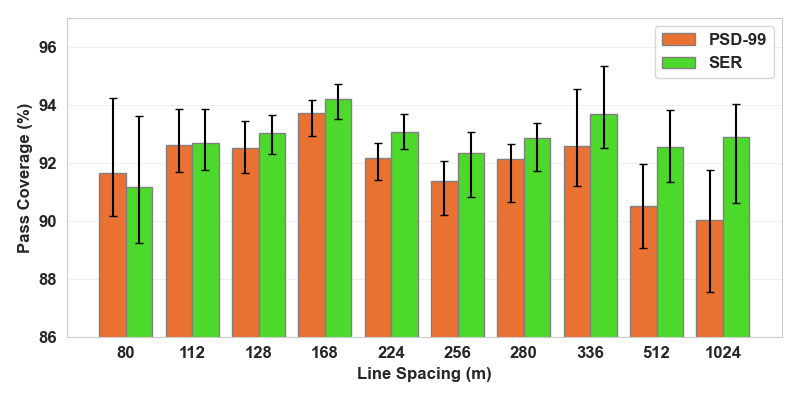

In [70]:
if bootstrap[0]:
    plot_pass_by_method_grouped_spacing(df=df_results,outdir=outdir,pass_percent=0)

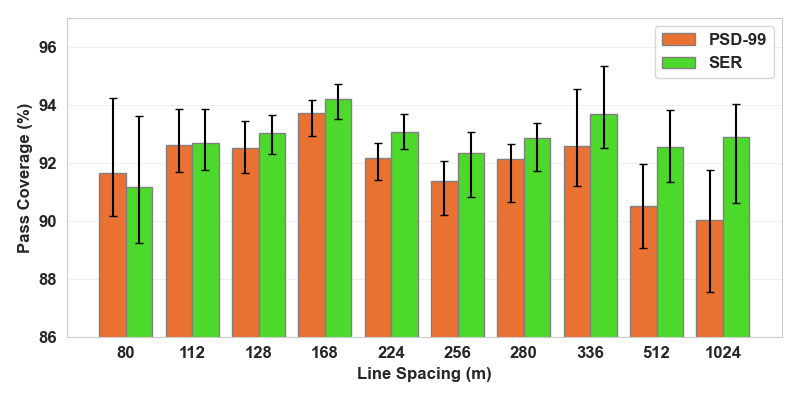

In [71]:
if bootstrap[0]:
    plot_pass_by_method_grouped_spacing(df=df_results,outdir=outdir,pass_percent=90)

In [73]:
if bootstrap[0]:
    plot_pass_by_method_grouped_spacing(df=df_results,outdir=outdir,pass_percent=95)

In [ ]:
aaaa

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def normalize_metrics_df(df_raw):
    """
    Normalize metrics so that higher = better for all.
    Input DataFrame columns:
      ['Seabed','Method','Spacing','Pass','RMSE','Bias','Std','Sharpness','Correlation']
    """
    df = df_raw.copy()

    # --- Convert numeric columns properly ---
    numeric_cols = ['Pass','RMSE','Bias','Std','Sharpness','Correlation']
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')  # convert strings, invalids -> NaN

    # --- Apply MinMax scaling ---
    scaler = MinMaxScaler()
    X = df[numeric_cols].to_numpy(dtype=float)
    X_scaled = scaler.fit_transform(X)

    # --- Build normalized metrics (higher = better) ---
    df_norm = pd.DataFrame(index=df.index)
    df_norm['coverage_s'] = X_scaled[:, numeric_cols.index('Pass')]              # high = good
    df_norm['rmse_s']     = 1.0 - X_scaled[:, numeric_cols.index('RMSE')]        # low = good
    df_norm['bias_s']     = 1.0 - np.abs(X_scaled[:, numeric_cols.index('Bias')]) # low = good
    df_norm['sharp_s']    = 1.0 - X_scaled[:, numeric_cols.index('Sharpness')]    # low = good
    df_norm['corr_s']     = X_scaled[:, numeric_cols.index('Correlation')]        # high = good

    # --- Clip ONLY normalized columns ---
    for col in ['coverage_s','rmse_s','bias_s','sharp_s','corr_s']:
        df_norm[col] = df_norm[col].clip(0.0, 1.0)

    # --- Add identifiers (untouched) ---
    df_norm['Seabed']  = df['Seabed']
    df_norm['Method']  = df['Method']
    df_norm['Spacing'] = df['Spacing']

    # --- Print summary ---
    summary = df_norm[['coverage_s','rmse_s','bias_s','sharp_s','corr_s']].agg(['min','median','mean','max']).T
    print("Normalized feature summary (higher = better):")
    print(summary.round(4))

    return df_norm, scaler

In [28]:
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.linear_model import LinearRegression
#
# def composite_score_orthogonal(
#     df,
#     weights,
#     group_cols=['Seabed', 'Method', 'Sampling'],
#     path='weight.csv',
#     expected_cols=None
# ):
#     """
#     Compute a composite score for performance metrics and summarize by both method and spacing.
#
#     Parameters
#     ----------
#     df : pd.DataFrame
#         Input dataframe with seabed, method, spacing, and metric columns.
#     weights : dict
#         Dictionary mapping standardized metric names (e.g. 'coverage_s', 'rmse_s') to weights.
#     group_cols : list
#         Columns to group by when summarizing.
#     path : str
#         Output Excel file path.
#     expected_cols : list or None
#         List of required columns. If None, defaults to the standard set.
#     """
#
#     # --- 1) Validate and normalize metrics ---
#     if expected_cols is None:
#         expected_cols = [
#             'Seabed', 'Method', 'Sampling', 'Spacing', 'Pass', 'RMSE', 'Bias', 'Correlation', 'Severity_score', 'Reliability_error','Uncertainty', 'Residuals']
#
#     missing = [c for c in expected_cols if c not in df.columns]
#     if missing:
#         raise ValueError(f"Missing required columns: {missing}")
#
#     df_stats = df.copy()
#
#     # --- 2) Automatically detect numeric columns (excluding group columns) ---
#     base_metrics = [c for c in expected_cols if c not in group_cols + ['Uncertainty', 'Residuals']]
#     numeric_cols = [
#         c for c in base_metrics
#         if pd.api.types.is_numeric_dtype(df_stats[c]) or np.issubdtype(df_stats[c].dtype, np.number)
#     ]
#
#     for c in numeric_cols:
#         df_stats[c] = pd.to_numeric(df_stats[c], errors='coerce')
#
#     # --- 3) Normalize ---
#     scaler = MinMaxScaler()
#     X_scaled = scaler.fit_transform(df_stats[numeric_cols])
#
#     df_norm = pd.DataFrame(index=df_stats.index)
#
#     # --- 4) Create standardized columns dynamically ---
#     for c in numeric_cols:
#         col_s = c.lower() + '_s'
#         if c.lower() in ['rmse', 'bias', 'std', 'sharpness', 'severity_score', 'reliability_error']:
#             df_norm[col_s] = 1 - np.abs(X_scaled[:, numeric_cols.index(c)])
#         else:
#             df_norm[col_s] = X_scaled[:, numeric_cols.index(c)]
#
#     # --- 5) Keep metadata columns ---
#     df_norm[group_cols + ['Spacing']] = df_stats[group_cols + ['Spacing']]
#
#     # Include raw metrics for reference
#     for c in numeric_cols:
#         df_norm[c] = df_stats[c]
#
#     # Clip standardized values
#     for c in df_norm.columns:
#         if c.endswith('_s'):
#             df_norm[c] = df_norm[c].clip(0, 1)
#
#     # --- 6) Compute composite score ---
#     weights_dict = weights
#     available_cols = [c for c in weights_dict.keys() if c in df_norm.columns]
#
#     if not available_cols:
#         raise ValueError("No matching standardized metric columns found for provided weights.")
#
#     df_norm['Composite_Score'] = sum(df_norm[c] * weights_dict[c] for c in available_cols)
#
#     # --- 7a) Summary by Seabed and Method (original) and Sampling ---
#     summary = (
#         df_norm.groupby(group_cols, as_index=False)[['Composite_Score']]
#         .mean()
#         .sort_values('Composite_Score', ascending=False))
#     # summary = (df_norm.groupby(group_cols, as_index=False).agg(
#     #     Composite_Score=('Composite_Score', 'mean'),
#     #     Sampling=('Sampling', 'first')).sort_values('Composite_Score', ascending=False))
#
#
#     # --- 7b) Summary by Spacing and Method (all methods) ---
#     summary_by_spacing = (
#         df_norm.groupby(['Spacing', 'Method'], as_index=False)[['Composite_Score']]
#         .mean()
#         .sort_values(['Spacing', 'Composite_Score'], ascending=[True, False]))
#
#     # --- 7c) Best method per spacing (top only) ---
#     best_per_spacing = (
#         summary_by_spacing.loc[
#             summary_by_spacing.groupby('Spacing')['Composite_Score'].idxmax()]
#         .reset_index(drop=True)
#         .sort_values('Spacing'))
#
#     # --- 7d) Best method per Sampling and Spacing ---
#     best_per_sampling_spacing = (
#         df_norm.groupby(['Sampling', 'Spacing', 'Method'], as_index=False)[['Composite_Score']].mean()
#         .loc[ lambda x: x.groupby(['Sampling', 'Spacing'])['Composite_Score'].idxmax() ].reset_index(drop=True)
#         .sort_values(['Sampling', 'Spacing']))
#
#     # --- 8) Export all to Excel ---
#     weights_df = pd.DataFrame({
#         'Feature': list(weights_dict.keys()),
#         'Weight': list(weights_dict.values()),
#     })
#
#     with pd.ExcelWriter(path, engine='xlsxwriter') as writer:
#         df_norm.to_excel(writer, sheet_name='Merged Data', index=False)
#         weights_df.to_excel(writer, sheet_name='Weights', index=False)
#         summary.to_excel(writer, sheet_name='Summary', index=False)
#         summary_by_spacing.to_excel(writer, sheet_name='Summary by Spacing (All)', index=False)
#         best_per_spacing.to_excel(writer, sheet_name='Best per Spacing', index=False)
#         best_per_sampling_spacing.to_excel(writer, sheet_name='Best per Sampling & Spacing',index=False)
#
#
#     return df_norm, weights_dict, summary, summary_by_spacing, best_per_spacing, best_per_sampling_spacing

In [29]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

def composite_score_orthogonal_new(
    df,
    weights,
    group_cols=['Seabed', 'Method', 'Sampling'],
    path='weight.csv',
    expected_cols=None,
    pass_threshold=95   # <<< ADDED
):
    """
    Compute a composite score for performance metrics and summarize by both method and spacing.
    """

    # --- 1) Validate and normalize metrics ---
    if expected_cols is None:
        expected_cols = [
            'Seabed', 'Method', 'Sampling', 'Spacing',
            'Pass', 'RMSE', 'MAE', 'Bias', 'Correlation',
            'Severity_score', 'Reliability_error', 'Over_penalty',
            'Uncertainty', 'Residuals'
        ]

    missing = [c for c in expected_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df_stats = df.copy()

    # --- 1b) APPLY PASS PERCENT THRESHOLD (HARD FILTER) ---
    df_stats = df_stats[round(df_stats['Pass']) >= pass_threshold].copy()

    if df_stats.empty:
        raise ValueError(
            f"No methods meet the Pass threshold of {pass_threshold:.2f}"
        )

    # --- 2) Automatically detect numeric columns ---
    base_metrics = [
        c for c in expected_cols
        if c not in group_cols + ['Uncertainty', 'Residuals']
    ]

    numeric_cols = [
        c for c in base_metrics
        if pd.api.types.is_numeric_dtype(df_stats[c])
        or np.issubdtype(df_stats[c].dtype, np.number)
    ]

    for c in numeric_cols:
        df_stats[c] = pd.to_numeric(df_stats[c], errors='coerce')

    # --- 3) Normalize ---
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(df_stats[numeric_cols])

    df_norm = pd.DataFrame(index=df_stats.index)

    # --- 4) Create standardized columns dynamically ---
    for c in numeric_cols:
        col_s = c.lower() + '_s'
        if c.lower() in [
            'rmse', 'bias', 'std', 'mae', 'over_penalty',
            'sharpness', 'severity_score', 'reliability_error'
        ]:
            df_norm[col_s] = 1 - np.abs(X_scaled[:, numeric_cols.index(c)])
        else:
            df_norm[col_s] = X_scaled[:, numeric_cols.index(c)]

    # --- 5) Keep metadata columns ---
    df_norm[group_cols + ['Spacing']] = df_stats[group_cols + ['Spacing']]

    # Include raw metrics for reference
    for c in numeric_cols:
        df_norm[c] = df_stats[c]

    # Clip standardized values
    for c in df_norm.columns:
        if c.endswith('_s'):
            df_norm[c] = df_norm[c].clip(0, 1)

    # --- 6) Compute composite score ---
    weights_dict = weights
    available_cols = [c for c in weights_dict.keys() if c in df_norm.columns]

    if not available_cols:
        raise ValueError(
            "No matching standardized metric columns found for provided weights."
        )

    df_norm['Composite_Score'] = sum(
        df_norm[c] * weights_dict[c] for c in available_cols
    )

    # --- 7a) Summary by Seabed, Method, Sampling ---
    summary = (
        df_norm.groupby(group_cols, as_index=False)[['Composite_Score']]
        .mean()
        .sort_values('Composite_Score', ascending=False)
    )

    # --- 7b) Summary by Spacing and Method ---
    summary_by_spacing = (
        df_norm.groupby(['Spacing', 'Method'], as_index=False)[['Composite_Score']]
        .mean()
        .sort_values(['Spacing', 'Composite_Score'], ascending=[True, False])
    )

    # --- 7c) Best method per spacing ---
    best_per_spacing = (
        summary_by_spacing.loc[
            summary_by_spacing.groupby('Spacing')['Composite_Score'].idxmax()
        ]
        .reset_index(drop=True)
        .sort_values('Spacing')
    )

    # --- 7d) Best method per Sampling and Spacing ---
    best_per_sampling_spacing = (
        df_norm.groupby(['Sampling', 'Spacing', 'Method'], as_index=False)[['Composite_Score']]
        .mean()
        .loc[
            lambda x: x.groupby(['Sampling', 'Spacing'])['Composite_Score'].idxmax()
        ]
        .reset_index(drop=True)
        .sort_values(['Sampling', 'Spacing'])
    )

    # --- 8) Export ---
    weights_df = pd.DataFrame({
        'Feature': list(weights_dict.keys()),
        'Weight': list(weights_dict.values()),
    })

    with pd.ExcelWriter(path, engine='xlsxwriter') as writer:
        df_norm.to_excel(writer, sheet_name='Merged Data', index=False)
        weights_df.to_excel(writer, sheet_name='Weights', index=False)
        summary.to_excel(writer, sheet_name='Summary', index=False)
        summary_by_spacing.to_excel(writer, sheet_name='Summary by Spacing (All)', index=False)
        best_per_spacing.to_excel(writer, sheet_name='Best per Spacing', index=False)
        best_per_sampling_spacing.to_excel(
            writer,
            sheet_name='Best per Sampling & Spacing',
            index=False
        )

    return (
        df_norm,
        weights_dict,
        summary,
        summary_by_spacing,
        best_per_spacing,
        best_per_sampling_spacing
    )

In [30]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.stats import kendalltau
# import itertools
# import os
# from typing import Dict, Tuple, List
#
# def systematic_weight_sweep_method(
#     df: pd.DataFrame,
#     feature_cols: List[str],
#     base_weights: Dict[str, float],
#     sweep_ranges: Dict[str, Tuple[float, float, int]],
#     top_k: int = 3,
#     out_prefix: str = "weight_sweep",
#     save_csv: bool = True,
#     seed: int = 0
# ):
#     np.random.seed(seed)
#
#     # --- sanity checks ---
#     missing = [c for c in feature_cols if c not in df.columns]
#     if missing:
#         raise ValueError(f"Missing feature columns in df: {missing}")
#     if 'Method' not in df.columns:
#         raise ValueError("DataFrame must have a 'Method' column for aggregation.")
#
#     # canonical baseline weights
#     w_base = {f: float(base_weights.get(f, 0.0)) for f in feature_cols}
#     s = sum(w_base.values())
#     if s <= 0:
#         raise ValueError("Base weights sum to zero or negative. Provide sensible base_weights.")
#     for k in w_base:
#         w_base[k] /= s
#
#     # baseline composite and ranking
#     def compute_composite_for_weights(weights_dict):
#         comps = df.copy()
#         vec = np.zeros(len(comps))
#         for f, w in weights_dict.items():
#             vec += w * comps[f].to_numpy()
#         comps['__composite__'] = vec
#         method_mean = comps.groupby('Method')['__composite__'].mean()
#         return method_mean
#
#     baseline_method_mean = compute_composite_for_weights(w_base)
#     baseline_ranking = baseline_method_mean.rank(ascending=False)
#     baseline_order = baseline_method_mean.sort_values(ascending=False)
#
#     # prepare sweep grid
#     sweep_keys = list(sweep_ranges.keys())
#     sweep_values = []
#     for k in sweep_keys:
#         lo, hi, n = sweep_ranges[k]
#         vals = np.linspace(lo, hi, n) if n > 1 else np.array([float(lo)])
#         sweep_values.append(vals)
#
#     grid = list(itertools.product(*sweep_values))
#     print(f"Total sweep points: {len(grid)} (this may be large)")
#
#     records = []
#     method_list = sorted(df['Method'].unique())
#
#     for idx, combo in enumerate(grid):
#         w_candidate = w_base.copy()
#         for k, val in zip(sweep_keys, combo):
#             w_candidate[k] = float(val)
#
#         summed = sum(w_candidate.values())
#         if summed > 0:
#             if abs(summed - 1.0) > 1e-12:
#                 for k in w_candidate:
#                     w_candidate[k] = w_candidate[k] / summed
#         else:
#             w_candidate = w_base.copy()
#
#         # compute composites
#         method_mean = compute_composite_for_weights(w_candidate)
#         method_mean = method_mean.reindex(method_list).fillna(0.0)
#         ranking = method_mean.rank(ascending=False)
#
#         # Kendall tau vs baseline
#         a = baseline_method_mean.reindex(method_list).to_numpy()
#         b = method_mean.to_numpy()
#         try:
#             tau, pval = kendalltau(a, b)
#         except Exception:
#             tau, pval = np.nan, np.nan
#
#         # top methods
#         top_methods = method_mean.sort_values(ascending=False).index.tolist()
#         top1 = top_methods[0] if len(top_methods) > 0 else None
#         top2 = top_methods[1] if len(top_methods) > 1 else None
#         top3 = top_methods[2] if len(top_methods) > 2 else None
#         topk = top_methods[:top_k]
#
#         rec = {f"w_{k}": float(w_candidate[k]) for k in feature_cols}
#         for k, val in zip(sweep_keys, combo):
#             rec[f"sweep_{k}"] = float(val)
#         rec['kendall_tau'] = float(tau) if not np.isnan(tau) else np.nan
#         rec['kendall_p'] = float(pval) if not np.isnan(pval) else np.nan
#         rec['top1'] = top1
#         rec['top2'] = top2
#         rec['top3'] = top3
#         rec['topk'] = ",".join(topk)
#         for m in method_list:
#             rec[f"comp_{m}"] = float(method_mean.get(m, 0.0))
#         records.append(rec)
#
#         if (idx + 1) % 1000 == 0:
#             print(f"Processed {idx + 1}/{len(grid)} sweep points...")
#
#     results_df = pd.DataFrame.from_records(records)
#
#     # --- diagnostics ---
#     taus = results_df['kendall_tau'].dropna().to_numpy()
#     mean_tau = float(np.nanmean(taus)) if taus.size > 0 else np.nan
#     std_tau = float(np.nanstd(taus)) if taus.size > 0 else np.nan
#
#     # frequency counts
#     top1_counts = results_df['top1'].value_counts().reindex(method_list).fillna(0).astype(int)
#     top2_counts = results_df['top2'].value_counts().reindex(method_list).fillna(0).astype(int)
#     top3_counts = results_df['top3'].value_counts().reindex(method_list).fillna(0).astype(int)
#
#     # percentage frequencies
#     n_points = len(results_df)
#     top1_freq_pct = (top1_counts / n_points * 100).round(2)
#     top2_freq_pct = (top2_counts / n_points * 100).round(2)
#     top3_freq_pct = (top3_counts / n_points * 100).round(2)
#
#     diagnostics_df = pd.DataFrame({
#         'Top1_Count': top1_counts,
#         'Top1_%': top1_freq_pct,
#         'Top2_Count': top2_counts,
#         'Top2_%': top2_freq_pct,
#         'Top3_Count': top3_counts,
#         'Top3_%': top3_freq_pct
#     }).fillna(0)
#
#     diagnostics = {
#         'n_points': n_points,
#         'mean_kendall_tau': mean_tau,
#         'std_kendall_tau': std_tau,
#     }
#
#     # --- save CSV + Excel ---
#     if save_csv:
#         # csv_path = f"{out_prefix}_weights_sensitivity_test_results.csv"
#         # results_df.to_csv(csv_path, index=False)
#         # print(f"Saved sweep results to: {csv_path}")
#
#         # also export Excel with diagnostics
#         excel_path = f"{out_prefix}_weights_sensitivity_results.xlsx"
#         with pd.ExcelWriter(excel_path, engine="xlsxwriter") as writer:
#             results_df.to_excel(writer, sheet_name="Results", index=False)
#             diagnostics_df.to_excel(writer, sheet_name="Diagnostics", index=True)
#         print(f"Saved Excel file (Results + Diagnostics) to: {excel_path}")
#
#     # --- plots ---
#     # 1) histogram of kendall tau
#     plt.figure(figsize=(6, 4))
#     plt.hist(taus, bins=30, edgecolor='k')
#     plt.xlabel("Kendall Tau (vs baseline)")
#     plt.ylabel("Frequency")
#     plt.title("Sweep: distribution of Kendall Tau")
#     plt.tight_layout()
#     hist_path = f"{out_prefix}_kendall_hist.png"
#     plt.savefig(hist_path, dpi=150)
#     plt.close()
#     print(f"Saved kendall-tau histogram to: {hist_path}")
#
#     # 2) Top-1, Top-2, Top-3 frequency subplots
#     fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=False)
#     axes[0].bar(top1_counts.index, top1_counts.values, color='green')
#     axes[0].set_title("Top-1 Frequency Across Sweep")
#     axes[0].set_ylabel("Count")
#
#     axes[1].bar(top2_counts.index, top2_counts.values, color='blue')
#     axes[1].set_title("Top-2 Frequency Across Sweep")
#     axes[1].set_ylabel("Count")
#
#     axes[2].bar(top3_counts.index, top3_counts.values, color='cyan')
#     axes[2].set_title("Top-3 Frequency Across Sweep")
#     axes[2].set_ylabel("Count")
#     axes[2].set_xlabel("Method")
#
#     for ax in axes:
#         ax.tick_params(axis='x', rotation=45)
#
#     plt.tight_layout()
#     bar_path = f"{out_prefix}_top_freqs.png"
#     plt.savefig(bar_path, dpi=150)
#     plt.close()
#     print(f"Saved top-1/2/3 frequency plots to: {bar_path}")
#
#     return results_df, diagnostics_df

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau
import itertools
import os
from typing import Dict, Tuple, List

def systematic_weight_sweep_method_orthogonal(
    df: pd.DataFrame,
    feature_cols: List[str],
    base_weights: Dict[str, float],
    sweep_ranges: Dict[str, Tuple[float, float, int]],
    top_k: int = 3,
    out_prefix: str = "weight_sweep",
    save_csv: bool = True,
    seed: int = 0,
    pass_threshold = 90,
):
    np.random.seed(seed)

    # --- sanity checks ---
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing feature columns in df: {missing}")
    if 'Method' not in df.columns or 'Sampling' not in df.columns:
        raise ValueError("DataFrame must have 'Method' and 'Sampling' columns.")

    # # Use pass threshold to screen methods
    # df = df[df['pass_percent'] >= pass_threshold].copy()
    #
    # if df.empty:
    #     raise ValueError(f"No methods meet the pass-percent threshold ({pass_threshold}).")

    # canonical baseline weights
    w_base = {f: float(base_weights.get(f, 0.0)) for f in feature_cols}
    s = sum(w_base.values())
    if s <= 0:
        raise ValueError("Base weights sum to zero or negative.")
    for k in w_base:
        w_base[k] /= s

    # baseline composite and ranking (Method + Sampling)
    def compute_composite_for_weights(weights_dict):
        comps = df.copy()
        vec = np.zeros(len(comps))
        for f, w in weights_dict.items():
            vec += w * comps[f].to_numpy()
        comps['__composite__'] = vec
        ms_mean = comps.groupby(['Method', 'Sampling'])['__composite__'].mean()
        return ms_mean

    baseline_ms_mean = compute_composite_for_weights(w_base)
    ms_index = baseline_ms_mean.index.tolist()

    # prepare sweep grid
    sweep_keys = list(sweep_ranges.keys())
    sweep_values = []
    for k in sweep_keys:
        lo, hi, n = sweep_ranges[k]
        vals = np.linspace(lo, hi, n) if n > 1 else np.array([float(lo)])
        sweep_values.append(vals)

    grid = list(itertools.product(*sweep_values))
    print(f"Total sweep points: {len(grid)}")

    records = []

    for idx, combo in enumerate(grid):
        w_candidate = w_base.copy()
        for k, val in zip(sweep_keys, combo):
            w_candidate[k] = float(val)

        summed = sum(w_candidate.values())
        if summed > 0 and abs(summed - 1.0) > 1e-12:
            for k in w_candidate:
                w_candidate[k] /= summed

        # compute composites
        ms_mean = compute_composite_for_weights(w_candidate)
        ms_mean = ms_mean.reindex(ms_index).fillna(0.0)

        # Kendall tau vs baseline
        a = baseline_ms_mean.reindex(ms_index).to_numpy()
        b = ms_mean.to_numpy()
        try:
            tau, pval = kendalltau(a, b)
        except Exception:
            tau, pval = np.nan, np.nan

        # ranking
        ordered = ms_mean.sort_values(ascending=False)
        top_ms = ordered.index.tolist()

        top1 = top_ms[0] if len(top_ms) > 0 else None
        top2 = top_ms[1] if len(top_ms) > 1 else None
        top3 = top_ms[2] if len(top_ms) > 2 else None
        topk = top_ms[:top_k]

        rec = {f"w_{k}": float(w_candidate[k]) for k in feature_cols}
        for k, val in zip(sweep_keys, combo):
            rec[f"sweep_{k}"] = float(val)

        rec['kendall_tau'] = float(tau) if not np.isnan(tau) else np.nan
        rec['kendall_p'] = float(pval) if not np.isnan(pval) else np.nan
        rec['top1'] = str(top1)
        rec['top2'] = str(top2)
        rec['top3'] = str(top3)
        rec['topk'] = ";".join([str(x) for x in topk])

        for (m, s) in ms_index:
            rec[f"comp_{m}_{s}"] = float(ms_mean.get((m, s), 0.0))

        records.append(rec)

        if (idx + 1) % 1000 == 0:
            print(f"Processed {idx + 1}/{len(grid)} sweep points...")

    results_df = pd.DataFrame.from_records(records)

    # --- diagnostics ---
    taus = results_df['kendall_tau'].dropna().to_numpy()
    mean_tau = float(np.nanmean(taus)) if taus.size > 0 else np.nan
    std_tau = float(np.nanstd(taus)) if taus.size > 0 else np.nan

    # frequency counts (Method + Sampling)
    top1_counts = results_df['top1'].value_counts()
    top2_counts = results_df['top2'].value_counts()
    top3_counts = results_df['top3'].value_counts()

    all_keys = sorted(set(top1_counts.index) |
                      set(top2_counts.index) |
                      set(top3_counts.index))

    top1_counts = top1_counts.reindex(all_keys).fillna(0).astype(int)
    top2_counts = top2_counts.reindex(all_keys).fillna(0).astype(int)
    top3_counts = top3_counts.reindex(all_keys).fillna(0).astype(int)

    n_points = len(results_df)

    diagnostics_df = pd.DataFrame({
        'Top1_Count': top1_counts,
        'Top1_%': (top1_counts / n_points * 100).round(2),
        'Top2_Count': top2_counts,
        'Top2_%': (top2_counts / n_points * 100).round(2),
        'Top3_Count': top3_counts,
        'Top3_%': (top3_counts / n_points * 100).round(2),
    })

    diagnostics = {
        'n_points': n_points,
        'mean_kendall_tau': mean_tau,
        'std_kendall_tau': std_tau,
    }

    # --- save ---
    if save_csv:
        excel_path = f"{out_prefix}_weights_sensitivity_results.xlsx"
        with pd.ExcelWriter(excel_path, engine="xlsxwriter") as writer:
            results_df.to_excel(writer, sheet_name="Results", index=False)
            diagnostics_df.to_excel(writer, sheet_name="Diagnostics")
        print(f"Saved Excel file to: {excel_path}")

    # --- plots ---
    plt.figure(figsize=(6, 4))
    plt.hist(taus, bins=30, edgecolor='k')
    plt.xlabel("Kendall Tau (vs baseline)")
    plt.ylabel("Frequency")
    plt.title("Sweep: distribution of Kendall Tau")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_kendall_hist.png", dpi=150)
    plt.close()

    fig, axes = plt.subplots(3, 1, figsize=(10, 10))
    axes[0].bar(top1_counts.index, top1_counts.values)
    axes[0].set_title("Top-1 Frequency (Method + Sampling)")

    axes[1].bar(top2_counts.index, top2_counts.values)
    axes[1].set_title("Top-2 Frequency (Method + Sampling)")

    axes[2].bar(top3_counts.index, top3_counts.values)
    axes[2].set_title("Top-3 Frequency (Method + Sampling)")
    axes[2].set_xlabel("Method | Sampling")

    for ax in axes:
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(f"{out_prefix}_top_freqs.png", dpi=150)
    plt.close()

    return results_df, diagnostics_df

In [32]:
# import matplotlib.pyplot as plt
#
# def systematic_weight_sweep_spacing(
#         df: pd.DataFrame,
#         feature_cols,
#         base_weights,
#         sweep_ranges,
#         groupby_cols=['Spacing', 'Method'],
#         top_k: int = 3,
#         out_prefix: str = "weight_sweep",
#         save_csv: bool = True,
#         seed: int = 0
# ):
#     np.random.seed(seed)
#
#     # Sanity checks
#     missing = [c for c in feature_cols if c not in df.columns]
#     if missing:
#         raise ValueError(f"Missing feature columns: {missing}")
#
#     # Normalize base weights
#     w_base = {f: float(base_weights.get(f, 0.0)) for f in feature_cols}
#     s = sum(w_base.values())
#     for k in w_base:
#         w_base[k] /= s
#
#     # Sweep grid
#     sweep_keys = list(sweep_ranges.keys())
#     sweep_values = [np.linspace(lo, hi, n) for lo, hi, n in sweep_ranges.values()]
#     grid = list(itertools.product(*sweep_values))
#     print(f"Total sweep points: {len(grid)}")
#
#     def compute_composite(weights_dict, df_subset):
#         comps = df_subset.copy()
#         vec = np.zeros(len(comps))
#         for f, w in weights_dict.items():
#             vec += w * comps[f].to_numpy()
#         comps["Composite_Score"] = vec
#         return comps.groupby(groupby_cols)["Composite_Score"].mean().reset_index()
#
#     all_results = []
#
#     # Perform sweeps
#     for idx, combo in enumerate(grid):
#         w_candidate = w_base.copy()
#         for k, val in zip(sweep_keys, combo):
#             w_candidate[k] = float(val)
#         summed = sum(w_candidate.values())
#         if summed > 0:
#             w_candidate = {k: v / summed for k, v in w_candidate.items()}
#
#         method_scores = compute_composite(w_candidate, df)
#         method_scores["Sweep_ID"] = idx
#         for k, v in w_candidate.items():
#             method_scores[f"w_{k}"] = v
#         all_results.append(method_scores)
#
#         if (idx + 1) % 500 == 0:
#             print(f"Processed {idx + 1}/{len(grid)} sweep points...")
#
#     results_df = pd.concat(all_results, ignore_index=True)
#
#     # === Rank and count ===
#     if groupby_cols == ['Spacing', 'Method']:
#         rankings = []
#         for spacing, subdf in results_df.groupby("Spacing"):
#             for sweep_id, sweep_df in subdf.groupby("Sweep_ID"):
#                 ranked = sweep_df.sort_values("Composite_Score", ascending=False)
#                 ranked["Rank"] = range(1, len(ranked) + 1)
#                 ranked["Spacing"] = spacing
#                 rankings.append(ranked)
#         ranked_df = pd.concat(rankings, ignore_index=True)
#
#         counts = (
#             ranked_df[ranked_df["Rank"] <= top_k]
#             .groupby(["Spacing", "Method", "Rank"])
#             .size()
#             .unstack("Rank", fill_value=0)
#             .rename(columns={1: "Top1_Count", 2: "Top2_Count", 3: "Top3_Count"})
#             .reset_index()
#         )
#
#         # === Create 6 subplots (one per spacing) ===
#         spacings = sorted(counts["Spacing"].unique())
#         n_spacings = len(spacings)
#         fig, axes = plt.subplots(
#             n_spacings, 1, figsize=(12, 3 * n_spacings), constrained_layout=True
#         )
#
#         if n_spacings == 1:
#             axes = [axes]  # make iterable
#
#         for ax, spacing in zip(axes, spacings):
#             sub = counts[counts["Spacing"] == spacing].copy()
#
#             # Get top 3 methods for each rank
#             top1 = sub.nlargest(3, "Top1_Count")[["Method", "Top1_Count"]]
#             top2 = sub.nlargest(3, "Top2_Count")[["Method", "Top2_Count"]]
#             top3 = sub.nlargest(3, "Top3_Count")[["Method", "Top3_Count"]]
#
#             # Merge and reshape
#             merged = (
#                 pd.merge(top1, top2, on="Method", how="outer")
#                 .merge(top3, on="Method", how="outer")
#                 .fillna(0)
#             )
#             melted = merged.melt(
#                 id_vars="Method",
#                 value_vars=["Top1_Count", "Top2_Count", "Top3_Count"],
#                 var_name="Rank",
#                 value_name="Count",
#             )
#
#             sns.barplot(
#                 data=melted,
#                 x="Rank",
#                 y="Count",
#                 hue="Method",
#                 ax=ax,
#                 palette="viridis",
#                 dodge=True,
#             )
#
#             ax.set_title(f"Top Methods at {spacing} m Spacing")
#             ax.set_ylabel("Count")
#             ax.set_xlabel("")
#             ax.legend(title="Method", bbox_to_anchor=(1.05, 1), loc="upper left")
#             ax.grid(axis="y", linestyle="--", alpha=0.5)
#
#         plt.suptitle("Top Methods Across Ranks and Spacings", fontsize=14, y=1.02)
#         plt.savefig(f"{out_prefix}_top_counts_subplot.png", dpi=300)
#         plt.close(fig)
#         print(f"Saved bar chart to: {out_prefix}_top_counts_subplot.png")
#
#     elif groupby_cols == ['Method']:
#         print("Currently this mode only supports ['Spacing','Method'] for ranking.")
#         counts = None
#
#     else:
#         raise ValueError("Only supports ['Method'] or ['Spacing','Method'].")
#
#     # === Diagnostics ===
#     from scipy.stats import kendalltau
#     baseline = results_df.groupby(groupby_cols)["Composite_Score"].mean().reset_index()
#     taus = []
#     for _, sweep_df in results_df.groupby("Sweep_ID"):
#         merged = pd.merge(
#             baseline,
#             sweep_df[groupby_cols + ["Composite_Score"]],
#             on=groupby_cols,
#             suffixes=("_base", "_sweep"),
#         )
#         tau, _ = kendalltau(
#             merged["Composite_Score_base"], merged["Composite_Score_sweep"]
#         )
#         taus.append(tau)
#     diagnostics_df = pd.DataFrame({
#         "Mean_Kendall_Tau": [np.nanmean(taus)],
#         "Std_Kendall_Tau": [np.nanstd(taus)]
#     })
#
#     # === Save ===
#     if save_csv:
#         excel_path = f"{out_prefix}_weights_sensitivity_results.xlsx"
#         with pd.ExcelWriter(excel_path, engine="xlsxwriter") as writer:
#             results_df.to_excel(writer, sheet_name="Results", index=False)
#             counts.to_excel(writer, sheet_name="Top_Methods_Counts", index=False)
#             diagnostics_df.to_excel(writer, sheet_name="Diagnostics", index=False)
#         print(f"Saved Excel file: {excel_path}")
#
#     return results_df, counts, diagnostics_df


In [33]:
# no percent
import matplotlib.pyplot as plt
import itertools
import numpy as np
import pandas as pd
import seaborn as sns

def systematic_weight_sweep_spacing_orthogonal(
        df: pd.DataFrame,
        feature_cols,
        base_weights,
        sweep_ranges,
        groupby_cols=['Spacing', 'Method', 'Sampling'],
        top_k: int = 3,
        out_prefix: str = "weight_sweep",
        save_csv: bool = True,
        seed: int = 0
):
    np.random.seed(seed)

    # Sanity checks
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing feature columns: {missing}")

    # Normalize base weights
    w_base = {f: float(base_weights.get(f, 0.0)) for f in feature_cols}
    s = sum(w_base.values())
    for k in w_base:
        w_base[k] /= s

    # Sweep grid
    sweep_keys = list(sweep_ranges.keys())
    sweep_values = [np.linspace(lo, hi, n) for lo, hi, n in sweep_ranges.values()]
    grid = list(itertools.product(*sweep_values))
    print(f"Total sweep points: {len(grid)}")

    def compute_composite(weights_dict, df_subset):
        comps = df_subset.copy()
        vec = np.zeros(len(comps))
        for f, w in weights_dict.items():
            vec += w * comps[f].to_numpy()
        comps["Composite_Score"] = vec
        return comps.groupby(groupby_cols)["Composite_Score"].mean().reset_index()

    all_results = []

    # Perform sweeps
    for idx, combo in enumerate(grid):
        w_candidate = w_base.copy()
        for k, val in zip(sweep_keys, combo):
            w_candidate[k] = float(val)

        summed = sum(w_candidate.values())
        if summed > 0:
            w_candidate = {k: v / summed for k, v in w_candidate.items()}

        method_scores = compute_composite(w_candidate, df)
        method_scores["Sweep_ID"] = idx
        for k, v in w_candidate.items():
            method_scores[f"w_{k}"] = v
        all_results.append(method_scores)

        if (idx + 1) % 500 == 0:
            print(f"Processed {idx + 1}/{len(grid)} sweep points...")

    results_df = pd.concat(all_results, ignore_index=True)

    # === Rank and count ===
    if groupby_cols == ['Spacing', 'Method', 'Sampling']:

        rankings = []
        for (sampling, spacing), subdf in results_df.groupby(["Sampling", "Spacing"]):
            for sweep_id, sweep_df in subdf.groupby("Sweep_ID"):
                ranked = sweep_df.sort_values("Composite_Score", ascending=False)
                ranked["Rank"] = range(1, len(ranked) + 1)
                ranked["Sampling"] = sampling
                ranked["Spacing"] = spacing
                rankings.append(ranked)

        ranked_df = pd.concat(rankings, ignore_index=True)

        counts = (
            ranked_df[ranked_df["Rank"] <= top_k]
            .groupby(["Sampling", "Spacing", "Method", "Rank"])
            .size()
            .unstack("Rank", fill_value=0)
            .rename(columns={1: "Top1_Count", 2: "Top2_Count", 3: "Top3_Count"})
            .reset_index()
        )

        # === Plotting (same logic, Sampling-aware) ===
        for sampling in sorted(counts["Sampling"].unique()):
            sub_samp = counts[counts["Sampling"] == sampling]
            spacings = sorted(sub_samp["Spacing"].unique())

            fig, axes = plt.subplots(
                len(spacings), 1,
                figsize=(12, 3 * len(spacings)),
                constrained_layout=True
            )

            if len(spacings) == 1:
                axes = [axes]

            for ax, spacing in zip(axes, spacings):
                sub = sub_samp[sub_samp["Spacing"] == spacing]

                top1 = sub.nlargest(3, "Top1_Count")[["Method", "Top1_Count"]]
                top2 = sub.nlargest(3, "Top2_Count")[["Method", "Top2_Count"]]
                top3 = sub.nlargest(3, "Top3_Count")[["Method", "Top3_Count"]]

                merged = (
                    pd.merge(top1, top2, on="Method", how="outer")
                    .merge(top3, on="Method", how="outer")
                    .fillna(0)
                )

                melted = merged.melt(
                    id_vars="Method",
                    value_vars=["Top1_Count", "Top2_Count", "Top3_Count"],
                    var_name="Rank",
                    value_name="Count"
                )

                sns.barplot(
                    data=melted,
                    x="Rank",
                    y="Count",
                    hue="Method",
                    ax=ax,
                    dodge=True
                )

                ax.set_title(f"Sampling: {sampling} | Spacing: {spacing}")
                ax.set_ylabel("Count")
                ax.set_xlabel("")
                ax.grid(axis="y", linestyle="--", alpha=0.5)

            plt.suptitle(
                f"Top Methods Across Ranks — Sampling = {sampling}",
                fontsize=14,
                y=1.02
            )

            plt.savefig(f"{out_prefix}_sampling_{sampling}_top_counts_subplot.png", dpi=300)
            plt.close(fig)

    elif groupby_cols == ['Method']:
        print("Currently this mode only supports ['Spacing','Method','Sampling'] for ranking.")
        counts = None

    else:
        raise ValueError("Only supports ['Spacing','Method','Sampling'].")

    # === Overall best method & sampling per spacing (based on sweep dominance) ===
    overall_best_per_spacing = (
        counts
        .sort_values(["Spacing", "Top1_Count"], ascending=[True, False])
        .groupby("Spacing", as_index=False)
        .first()
    )

    # === Diagnostics (unchanged) ===
    from scipy.stats import kendalltau
    baseline = results_df.groupby(groupby_cols)["Composite_Score"].mean().reset_index()

    taus = []
    for _, sweep_df in results_df.groupby("Sweep_ID"):
        merged = pd.merge(
            baseline,
            sweep_df[groupby_cols + ["Composite_Score"]],
            on=groupby_cols,
            suffixes=("_base", "_sweep"),
        )
        tau, _ = kendalltau(
            merged["Composite_Score_base"], merged["Composite_Score_sweep"]
        )
        taus.append(tau)

    diagnostics_df = pd.DataFrame({
        "Mean_Kendall_Tau": [np.nanmean(taus)],
        "Std_Kendall_Tau": [np.nanstd(taus)]
    })

    # === Save ===
    if save_csv:
        excel_path = f"{out_prefix}_weights_sensitivity_results.xlsx"
        with pd.ExcelWriter(excel_path, engine="xlsxwriter") as writer:
            results_df.to_excel(writer, sheet_name="Results", index=False)
            counts.to_excel(writer, sheet_name="Top_Methods_Counts", index=False)
            overall_best_per_spacing.to_excel(writer,sheet_name="Overall Best per Spacing", index=False)

            diagnostics_df.to_excel(writer, sheet_name="Diagnostics", index=False)

        print(f"Saved Excel file: {excel_path}")

    return results_df, counts, diagnostics_df


In [34]:
# # no percent +
# import matplotlib.pyplot as plt
# import itertools
# import numpy as np
# import pandas as pd
# import seaborn as sns
#
# def systematic_weight_sweep_spacing_orthogonal(
#         df: pd.DataFrame,
#         feature_cols,
#         base_weights,
#         sweep_ranges,
#         groupby_cols=['Spacing', 'Method', 'Sampling'],
#         top_k: int = 3,
#         out_prefix: str = "weight_sweep",
#         save_csv: bool = True,
#         seed: int = 0,
#         compare_ml = True,
#         pass_threshold = 0.95
# ):
#     np.random.seed(seed)
#
#     # Sanity checks
#     missing = [c for c in feature_cols if c not in df.columns]
#     if missing:
#         raise ValueError(f"Missing feature columns: {missing}")
#
#     # # Use pass threshold to screen methods
#     # df = df[df['pass_percent'] >= pass_threshold].copy()
#     #
#     # if df.empty:
#     #     raise ValueError(f"No methods meet the pass-percent threshold ({pass_threshold}).")
#
#     # Normalize base weights
#     w_base = {f: float(base_weights.get(f, 0.0)) for f in feature_cols}
#     s = sum(w_base.values())
#     for k in w_base:
#         w_base[k] /= s
#
#     # Sweep grid
#     sweep_keys = list(sweep_ranges.keys())
#     sweep_values = [np.linspace(lo, hi, n) for lo, hi, n in sweep_ranges.values()]
#     grid = list(itertools.product(*sweep_values))
#     print(f"Total sweep points: {len(grid)}")
#
#     def compute_composite(weights_dict, df_subset):
#         comps = df_subset.copy()
#         vec = np.zeros(len(comps))
#         for f, w in weights_dict.items():
#             vec += w * comps[f].to_numpy()
#         comps["Composite_Score"] = vec
#         return comps.groupby(groupby_cols)["Composite_Score"].mean().reset_index()
#
#     all_results = []
#
#     # Perform sweeps
#     for idx, combo in enumerate(grid):
#         w_candidate = w_base.copy()
#         for k, val in zip(sweep_keys, combo):
#             w_candidate[k] = float(val)
#
#         summed = sum(w_candidate.values())
#         if summed > 0:
#             w_candidate = {k: v / summed for k, v in w_candidate.items()}
#
#         method_scores = compute_composite(w_candidate, df)
#         method_scores["Sweep_ID"] = idx
#         for k, v in w_candidate.items():
#             method_scores[f"w_{k}"] = v
#         all_results.append(method_scores)
#
#         if (idx + 1) % 500 == 0:
#             print(f"Processed {idx + 1}/{len(grid)} sweep points...")
#
#     results_df = pd.concat(all_results, ignore_index=True)
#
#
#     # Mean Composite score
#     mean_composite_stats = (results_df.groupby(["Sampling", "Spacing", "Method"])["Composite_Score"] .mean().reset_index(name="Mean_Composite"))
#     best_by_mean_composite = (mean_composite_stats.sort_values(["Sampling", "Spacing", "Mean_Composite"], ascending=[True, True, False]).groupby(["Sampling", "Spacing"], as_index=False).first())
#
#     overall_composite_stats = (mean_composite_stats.groupby(["Sampling", "Method"])["Mean_Composite"].mean().reset_index(name="Mean_of_Mean_Composite").sort_values(["Sampling", "Mean_of_Mean_Composite"], ascending=[True, False]))
#
#     best_global_composite = (overall_composite_stats.groupby("Sampling", as_index=False).first())
#
#     # Coverage aware composite score
#     coverage = (mean_composite_stats.groupby(["Sampling", "Method"])["Spacing"].nunique().reset_index(name="Coverage_Count"))
#     total_spacings = mean_composite_stats["Spacing"].nunique()
#     coverage["Coverage_Ratio"] = coverage["Coverage_Count"] / total_spacings
#     overall = (mean_composite_stats.groupby(["Sampling", "Method"])["Mean_Composite"].mean().reset_index())
#     overall = overall.merge(coverage, on=["Sampling", "Method"])
#     overall["Coverage_Adjusted_Score"] = (overall["Mean_Composite"] * overall["Coverage_Ratio"])
#
#
#     # export df
#     df_stats = df[["Sampling", "Spacing", "Method", "Pass", "Composite_Score"]]
#     # =========================
#     # REGRET-BASED ROBUSTNESS
#     # =========================
#
#     # compute regret within each sweep
#     regret_dfs = []
#
#     for (sampling, spacing, sweep_id), sweep_df in results_df.groupby(
#         ["Sampling", "Spacing", "Sweep_ID"]):
#         sweep_df = sweep_df.copy()
#         best_score = sweep_df["Composite_Score"].max()
#         sweep_df["Regret"] = best_score - sweep_df["Composite_Score"]
#         regret_dfs.append(sweep_df)
#     regret_df = pd.concat(regret_dfs, ignore_index=True)
#
#     # # expected regret per method
#     # expected_regret = (
#     #     regret_df
#     #     .groupby(["Sampling", "Spacing", "Method"])["Regret"]
#     #     .mean()
#     #     .reset_index()
#     # )
#
#     #     # best method per spacing (and sampling if needed)
#     # best_by_regret = (
#     #     expected_regret
#     #     .sort_values(["Sampling", "Spacing", "Regret"], ascending=[True, True, True])
#     #     .groupby(["Sampling", "Spacing"], as_index=False)
#     #     .first()
#     # )
#     #
#     # overall_regret_across_spacings = (expected_regret.groupby(["Sampling", "Method"])["Regret"].mean().reset_index())
#     # best_method_regret_global = (overall_regret_across_spacings.sort_values(["Sampling", "Regret"]).groupby("Sampling", as_index=False).first())
#
#     regret_stats = (
#         regret_df
#         .groupby(["Sampling", "Spacing", "Method"])
#         .agg(
#             Mean_Regret=("Regret", "mean"),
#             Std_Regret=("Regret", "std"),
#             Max_Regret=("Regret", "max"),
#             P90_Regret=("Regret", lambda x: np.percentile(x, 90))
#         )
#         .reset_index()
#     )
#
#     best_by_mean = (
#     regret_stats
#     .sort_values(["Sampling", "Spacing", "Mean_Regret"])
#     .groupby(["Sampling", "Spacing"], as_index=False)
#     .first())
#
#     best_by_max = (
#     regret_stats
#     .sort_values(["Sampling", "Spacing", "Max_Regret"])
#     .groupby(["Sampling", "Spacing"], as_index=False)
#     .first())
#
#     overall_stats = (
#         regret_stats
#         .groupby(["Sampling", "Method"])
#         .agg(
#             Mean_of_Mean=("Mean_Regret", "mean"),
#             Mean_of_Std=("Std_Regret", "mean"),
#             Max_of_Max=("Max_Regret", "max"),
#             P90_of_P90=("P90_Regret", "mean")
#         ).sort_values("Mean_of_Mean", ascending=True)
#         .reset_index()
#     )
#
#     best_global_mean = (
#     overall_stats
#     .sort_values(["Sampling", "Mean_of_Mean"])
#     .groupby("Sampling", as_index=False)
#     .first())
#
#     best_global_safe = (
#     overall_stats
#     .sort_values(["Sampling", "Max_of_Max"])
#     .groupby("Sampling", as_index=False)
#     .first())
#
#     # coverage-aware regret analysis
#     # === COVERAGE PER METHOD ===
#     coverage = (
#         regret_stats
#         .groupby(["Sampling", "Method"])["Spacing"]
#         .nunique()
#         .reset_index(name="Coverage_Count"))
#
#     total_spacings = regret_stats["Spacing"].nunique()
#
#     coverage["Coverage_Ratio"] = coverage["Coverage_Count"] / total_spacings
#
#     regret_stats = regret_stats.merge(
#     coverage[["Sampling", "Method", "Coverage_Ratio"]],
#     on=["Sampling", "Method"],
#     how="left")
#
#     regret_stats["Adj_Mean_Regret"] = (
#     regret_stats["Mean_Regret"] / regret_stats["Coverage_Ratio"])
#
#     regret_stats["Adj_Max_Regret"] = (
#     regret_stats["Max_Regret"] / regret_stats["Coverage_Ratio"])
#
#     best_by_mean_adj = (
#     regret_stats
#     .sort_values(["Sampling", "Spacing", "Adj_Mean_Regret"])
#     .groupby(["Sampling", "Spacing"], as_index=False)
#     .first())
#
#     best_by_max_adj = (
#         regret_stats
#         .sort_values(["Sampling", "Spacing", "Adj_Max_Regret"])
#         .groupby(["Sampling", "Spacing"], as_index=False)
#         .first()
#     )
#
#     overall_adj_stats = (regret_stats.groupby(["Sampling", "Method"]).agg(
#         Mean_of_AdjMean=("Adj_Mean_Regret", "mean"),
#         Max_of_AdjMax=("Adj_Max_Regret", "max")).reset_index())
#
#     best_global_adj_mean = (overall_adj_stats.sort_values(["Sampling", "Mean_of_AdjMean"]).groupby("Sampling", as_index=False).first())
#
#     best_global_adj_safe = (overall_adj_stats.sort_values(["Sampling", "Max_of_AdjMax"]).groupby("Sampling", as_index=False).first())
#
#     # === Rank and count ===
#     if groupby_cols == ['Spacing', 'Method', 'Sampling']:
#
#         rankings = []
#         for (sampling, spacing), subdf in results_df.groupby(["Sampling", "Spacing"]):
#             for sweep_id, sweep_df in subdf.groupby("Sweep_ID"):
#                 ranked = sweep_df.sort_values("Composite_Score", ascending=False)
#                 ranked["Rank"] = range(1, len(ranked) + 1)
#                 ranked["Sampling"] = sampling
#                 ranked["Spacing"] = spacing
#                 rankings.append(ranked)
#
#         ranked_df = pd.concat(rankings, ignore_index=True)
#
#         # counts = (
#         #     ranked_df[ranked_df["Rank"] <= top_k]
#         #     .groupby(["Sampling", "Spacing", "Method", "Rank"])
#         #     .size()
#         #     .unstack("Rank", fill_value=0)
#         #     .rename(columns={1: "Top1_Count", 2: "Top2_Count", 3: "Top3_Count"})
#         #     .reset_index()
#         # )
#
#         counts = (
#             ranked_df[ranked_df["Rank"] <= top_k]
#             .groupby(["Sampling", "Spacing", "Method", "Rank"])
#             .size()
#             .unstack("Rank", fill_value=0)
#         )
#
#         for r in range(1, top_k + 1):
#             if r not in counts.columns:
#                 counts[r] = 0
#
#         counts = (
#             counts
#             .rename(columns={1: "Top1_Count", 2: "Top2_Count", 3: "Top3_Count"})
#             .reset_index()
#         )
#
#         # # === Plotting (unchanged) ===
#         # for sampling in sorted(counts["Sampling"].unique()):
#         #     sub_samp = counts[counts["Sampling"] == sampling]
#         #     spacings = sorted(sub_samp["Spacing"].unique())
#         #
#         #     fig, axes = plt.subplots(
#         #         len(spacings), 1,
#         #         figsize=(12, 3 * len(spacings)),
#         #         constrained_layout=True
#         #     )
#         #
#         #     if len(spacings) == 1:
#         #         axes = [axes]
#         #
#         #     for ax, spacing in zip(axes, spacings):
#         #         sub = sub_samp[sub_samp["Spacing"] == spacing]
#         #
#         #         top1 = sub.nlargest(3, "Top1_Count")[["Method", "Top1_Count"]]
#         #         top2 = sub.nlargest(3, "Top2_Count")[["Method", "Top2_Count"]]
#         #         top3 = sub.nlargest(3, "Top3_Count")[["Method", "Top3_Count"]]
#         #
#         #         merged = (
#         #             pd.merge(top1, top2, on="Method", how="outer")
#         #             .merge(top3, on="Method", how="outer")
#         #             .fillna(0)
#         #         )
#         #
#         #         melted = merged.melt(
#         #             id_vars="Method",
#         #             value_vars=["Top1_Count", "Top2_Count", "Top3_Count"],
#         #             var_name="Rank",
#         #             value_name="Count"
#         #         )
#         #
#         #         sns.barplot(
#         #             data=melted,
#         #             x="Rank",
#         #             y="Count",
#         #             hue="Method",
#         #             ax=ax,
#         #             dodge=True
#         #         )
#         #
#         #         ax.set_title(f"Sampling: {sampling} | Spacing: {spacing}")
#         #         ax.set_ylabel("Count")
#         #         ax.set_xlabel("")
#         #         ax.grid(axis="y", linestyle="--", alpha=0.5)
#         #
#         #     plt.suptitle(
#         #         f"Top Methods Across Ranks — Sampling = {sampling}",
#         #         fontsize=14,
#         #         y=1.02
#         #     )
#         #
#         #     plt.savefig(f"{out_prefix}_sampling_{sampling}_tc.png", dpi=300)
#         #     plt.close(fig)
#
#     else:
#         raise ValueError("Only supports ['Spacing','Method','Sampling'].")
#
#     # === Overall best per Sampling × Spacing ===
#     overall_best_per_sampling_spacing = (
#         counts
#         .sort_values(["Sampling", "Spacing", "Top1_Count"], ascending=[True, True, False])
#         .groupby(["Sampling", "Spacing"], as_index=False)
#         .first())
#
#     # # remove later
#     # # === Overall best per Spacing (aggregated across Sampling) ===
#     # overall_best_per_spacing_agg = (
#     #     counts
#     #     .groupby(["Spacing", "Method"], as_index=False)[["Top1_Count", "Top2_Count", "Top3_Count"]]
#     #     .sum()
#     #     .sort_values(["Spacing", "Top1_Count"], ascending=[True, False])
#     #     .groupby("Spacing", as_index=False)
#     #     .first()
#     # )
#
#     # === Overall best method & sampling per spacing (based on sweep dominance) ===
#     overall_best_per_spacing_dominance = (
#         counts
#         .sort_values(["Spacing", "Top1_Count"], ascending=[True, False])
#         .groupby("Spacing", as_index=False)
#         .first()
#     )
#
#     # === Top 3 Overall Methods Across Spacings (Top1 Dominance Only) ===
#     n_spacings = counts["Spacing"].nunique()
#
#     overall_top3_across_spacings = (
#         counts
#         .groupby(["Sampling", "Method"], as_index=False)["Top1_Count"]
#         .sum()
#     )
#
#     # # Normalize by total number of spacings (coverage-aware)
#     # overall_top3_across_spacings["Top1_Normalized"] = (
#     #     overall_top3_across_spacings["Top1_Count"] / n_spacings
#     # )
#     #
#     # Rank methods by dominance within each Sampling
#     overall_top3_across_spacings = (
#         overall_top3_across_spacings
#         .sort_values(["Sampling", "Top1_Count"], ascending=[True, False])
#     )
#
#     # Extract top 3 per Sampling
#     overall_top3_across_spacings = (
#         overall_top3_across_spacings
#         .groupby("Sampling")
#         .head(3)
#         .reset_index(drop=True)
#     )
#
#     # Percent share of total Top1 dominance within each Sampling
#     overall_top3_across_spacings["Top1_Percent"] = (
#         overall_top3_across_spacings
#         .groupby("Sampling")["Top1_Count"]
#         .transform(lambda x: x / x.sum() * 100)
#     )
#
#
#     # # === Diagnostics (unchanged) ===
#     # from scipy.stats import kendalltau
#     # baseline = results_df.groupby(groupby_cols)["Composite_Score"].mean().reset_index()
#     #
#     # taus = []
#     # for _, sweep_df in results_df.groupby("Sweep_ID"):
#     #     merged = pd.merge(
#     #         baseline,
#     #         sweep_df[groupby_cols + ["Composite_Score"]],
#     #         on=groupby_cols,
#     #         suffixes=("_base", "_sweep"),
#     #     )
#     #     tau, _ = kendalltau(
#     #         merged["Composite_Score_base"], merged["Composite_Score_sweep"]
#     #     )
#     #     taus.append(tau)
#     #
#     # diagnostics_df = pd.DataFrame({
#     #     "Mean_Kendall_Tau": [np.nanmean(taus)],
#     #     "Std_Kendall_Tau": [np.nanstd(taus)]
#     # })
#
#     if compare_ml:
#         # === Identify overall best method across spacings (from Top1 dominance) ===
#         overall_best_method = (
#             overall_top3_across_spacings
#             .groupby("Sampling")
#             .head(1)
#             .reset_index(drop=True)
#         )
#
#         # Ensure it's a classical method
#         overall_best_classical = []
#         for _, row in overall_best_method.iterrows():
#             if "ML" not in row["Method"]:
#                 overall_best_classical.append(row)
#             else:
#                 next_best = overall_top3_across_spacings[
#                     (overall_top3_across_spacings["Sampling"] == row["Sampling"]) &
#                     (~overall_top3_across_spacings["Method"].str.contains("ML"))
#                 ].head(1)
#                 if not next_best.empty:
#                     overall_best_classical.append(next_best.iloc[0])
#         best_classical_df = pd.DataFrame(overall_best_classical)
#
#         mri_list = []
#
#         for (sampling, spacing, sweep_id), subdf in results_df.groupby(["Sampling", "Spacing", "Sweep_ID"]):
#             ml_methods = [m for m in subdf["Method"].unique() if "ML" in m]
#             if not ml_methods:
#                 continue
#
#             # Get the best classical method for this Sampling
#             best_row = best_classical_df[best_classical_df["Sampling"] == sampling]
#             if best_row.empty:
#                 # No classical method available for this sampling, skip
#                 continue
#
#             best_classical_method = best_row["Method"].values[0]
#             classical_score_series = subdf[subdf["Method"] == best_classical_method]["Composite_Score"]
#             if classical_score_series.empty:
#                 # Method not present in this sweep, skip
#                 continue
#             best_classical_score = classical_score_series.values[0]
#
#             for ml_m in ml_methods:
#                 ml_score_series = subdf[subdf["Method"] == ml_m]["Composite_Score"]
#                 if ml_score_series.empty:
#                     continue
#                 ml_score = ml_score_series.values[0]
#                 mri = (ml_score - best_classical_score) / best_classical_score * 100
#                 mri_list.append({
#                     "Sampling": sampling,
#                     "Spacing": spacing,
#                     "Sweep_ID": sweep_id,
#                     "ML_Method": ml_m,
#                     "Best_Classical_Method": best_classical_method,
#                     "Best_Classical_Score": best_classical_score,
#                     "ML_Score": ml_score,
#                     "MRI_percent": mri
#                 })
#
#         mri_df = pd.DataFrame(mri_list)
#         mean_mri_percent = mri_df["MRI_percent"].mean() if not mri_df.empty else np.nan
#         print(f"Mean Relative Improvement of ML over best classical method: {mean_mri_percent:.2f}%")
#
#
#     # === Save ===
#     if save_csv:
#         excel_path = f"{out_prefix}_weights_sensitivity_results.xlsx"
#         with pd.ExcelWriter(excel_path, engine="xlsxwriter") as writer:
#             df_stats.to_excel(writer, sheet_name="Statistics", index=False)
#             results_df.to_excel(writer, sheet_name="Results", index=False)
#             counts.to_excel(writer, sheet_name="Top_Methods_Counts", index=False)
#             overall_best_per_sampling_spacing.to_excel(writer, sheet_name="Best per Sampling & Spacing", index=False)
#             # overall_best_per_spacing_dominance.to_excel(writer, sheet_name="Best per Spacing Dominance", index=False)
#             overall_top3_across_spacings.to_excel(writer, sheet_name="Top3 Across Spacings",index=False )
#
#
#             # BEST METHODS PER SPACING
#             best_by_mean.to_excel(writer, sheet_name="Best_by_Mean_Regret", index=False)
#             best_by_max.to_excel(writer, sheet_name="Best_by_Max_Regret", index=False)
#
#
#             # GLOBAL (ACROSS SPACINGS)
#             overall_stats.to_excel(writer, sheet_name="Global_Regret_Stats", index=False)
#             best_global_mean.to_excel(writer, sheet_name="Best_Global_Mean", index=False)
#             best_global_safe.to_excel(writer, sheet_name="Best_Global_Safe", index=False)
#             best_global_composite.to_excel(writer, sheet_name="Best_Global_Composite", index=False)
#
#             regret_df.to_excel(writer, sheet_name="Regret_All_Sweeps", index=False)
#             regret_stats.to_excel(writer, sheet_name="Regret_Stats_per_Spacing", index=False)
#             best_by_mean_composite.to_excel(writer, sheet_name="Best_by_Mean_Composite", index=False)
#             mean_composite_stats.to_excel(writer, sheet_name="Mean_Composite_Stats", index=False)
#             overall_composite_stats.to_excel(writer, sheet_name="Global_Composite_Stats", index=False)
#             overall.to_excel(writer, sheet_name="Coverage_Global_Composite_Stats", index=False)
#             # expected_regret.to_excel(writer, sheet_name="Expected_Regret", index=False)
#             # best_by_regret.to_excel(writer, sheet_name="Best_by_Regret", index=False)
#             # overall_regret_across_spacings.to_excel(writer, sheet_name="Overall Regret", index=False)
#             # best_method_regret_global.to_excel(writer, sheet_name="Best Method Regret", index=False)
#
#
#
#             # coverage aware regret analysis
#             coverage.to_excel(writer, sheet_name="Coverage", index=False)
#             regret_stats.to_excel(writer, sheet_name="Regret_with_Coverage", index=False)
#
#             best_by_mean_adj.to_excel(writer, sheet_name="Best_by_AdjMean", index=False)
#             best_by_max_adj.to_excel(writer, sheet_name="Best_by_AdjMax", index=False)
#
#             overall_adj_stats.to_excel(writer, sheet_name="Global_Adj_Regret", index=False)
#             best_global_adj_mean.to_excel(writer, sheet_name="Best_Global_AdjMean", index=False)
#             best_global_adj_safe.to_excel(writer, sheet_name="Best_Global_AdjSafe", index=False)
#
#             if compare_ml:
#                 mri_df.to_excel(writer, sheet_name="MRI_Percent", index=False)
#                 # Optional: also save the mean MRI as a separate sheet
#                 pd.DataFrame({"Mean_MRI_percent": [mean_mri_percent]}).to_excel( writer, sheet_name="MRI_Summary", index=False)
#
#             # overall_best_per_spacing_agg.to_excel(writer, sheet_name="Best per Spacing Agg.", index=False )
#             # diagnostics_df.to_excel(writer, sheet_name="Diagnostics", index=False)
#
#         print(f"Saved Excel file: {excel_path}")
#
#     # return results_df, counts, diagnostics_df
#     return results_df, counts


## Cleaned version

In [35]:
# no percent +
import matplotlib.pyplot as plt
import itertools
import numpy as np
import pandas as pd
import seaborn as sns

def systematic_weight_sweep_spacing_orthogonal(
        df: pd.DataFrame,
        feature_cols,
        base_weights,
        sweep_ranges,
        groupby_cols=['Spacing', 'Method', 'Sampling'],
        top_k: int = 3,
        out_prefix: str = "weight_sweep",
        save_csv: bool = True,
        seed: int = 0,
        compare_ml = True,
        pass_threshold = 0.95
):
    np.random.seed(seed)

    # Sanity checks
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing feature columns: {missing}")

    # Normalize base weights
    w_base = {f: float(base_weights.get(f, 0.0)) for f in feature_cols}
    s = sum(w_base.values())
    for k in w_base:
        w_base[k] /= s

    # Sweep grid
    sweep_keys = list(sweep_ranges.keys())
    sweep_values = [np.linspace(lo, hi, n) for lo, hi, n in sweep_ranges.values()]
    grid = list(itertools.product(*sweep_values))
    print(f"Total sweep points: {len(grid)}")

    def compute_composite(weights_dict, df_subset):
        comps = df_subset.copy()
        vec = np.zeros(len(comps))
        for f, w in weights_dict.items():
            vec += w * comps[f].to_numpy()
        comps["Composite_Score"] = vec
        return comps.groupby(groupby_cols)["Composite_Score"].mean().reset_index()

    all_results = []

    # Perform sweeps
    for idx, combo in enumerate(grid):
        w_candidate = w_base.copy()
        for k, val in zip(sweep_keys, combo):
            w_candidate[k] = float(val)

        summed = sum(w_candidate.values())
        if summed > 0:
            w_candidate = {k: v / summed for k, v in w_candidate.items()}

        method_scores = compute_composite(w_candidate, df)
        method_scores["Sweep_ID"] = idx
        for k, v in w_candidate.items():
            method_scores[f"w_{k}"] = v
        all_results.append(method_scores)

        if (idx + 1) % 500 == 0:
            print(f"Processed {idx + 1}/{len(grid)} sweep points...")

    results_df = pd.concat(all_results, ignore_index=True)


    # Mean Composite score
    mean_composite_stats = (results_df.groupby(["Sampling", "Spacing", "Method"])["Composite_Score"] .mean().reset_index(name="Mean_Composite"))
    best_by_mean_composite = (mean_composite_stats.sort_values(["Sampling", "Spacing", "Mean_Composite"], ascending=[True, True, False]).groupby(["Sampling", "Spacing"], as_index=False).first())

    overall_composite_stats = (mean_composite_stats.groupby(["Sampling", "Method"])["Mean_Composite"].mean().reset_index(name="Mean_of_Mean_Composite").sort_values(["Sampling", "Mean_of_Mean_Composite"], ascending=[True, False]))

    best_global_composite = (overall_composite_stats.groupby("Sampling", as_index=False).first())

    # Coverage aware composite score
    coverage = (mean_composite_stats.groupby(["Sampling", "Method"])["Spacing"].nunique().reset_index(name="Coverage_Count"))
    total_spacings = mean_composite_stats["Spacing"].nunique()
    coverage["Coverage_Ratio"] = coverage["Coverage_Count"] / total_spacings
    overall = (mean_composite_stats.groupby(["Sampling", "Method"])["Mean_Composite"].mean().reset_index())
    overall = overall.merge(coverage, on=["Sampling", "Method"])
    overall["Coverage_Adjusted_Score"] = (overall["Mean_Composite"] * overall["Coverage_Ratio"])
    overall.sort_values("Coverage_Adjusted_Score", ascending=False)
    best_global_adj_composite = (overall.groupby("Sampling", as_index=False).first())

    # export df
    df_stats = df[["Sampling", "Spacing", "Method", "Pass", "Composite_Score"]]
    # =========================
    # REGRET-BASED ROBUSTNESS
    # =========================

    # compute regret within each sweep
    regret_dfs = []

    for (sampling, spacing, sweep_id), sweep_df in results_df.groupby(
        ["Sampling", "Spacing", "Sweep_ID"]):
        sweep_df = sweep_df.copy()
        best_score = sweep_df["Composite_Score"].max()
        sweep_df["Regret"] = best_score - sweep_df["Composite_Score"]
        regret_dfs.append(sweep_df)
    regret_df = pd.concat(regret_dfs, ignore_index=True)

    regret_stats = (
        regret_df
        .groupby(["Sampling", "Spacing", "Method"])
        .agg(
            Mean_Regret=("Regret", "mean"),
            Std_Regret=("Regret", "std"),
            Max_Regret=("Regret", "max"),
            P90_Regret=("Regret", lambda x: np.percentile(x, 90))
        )
        .reset_index()
    )

    best_by_mean = (
    regret_stats
    .sort_values(["Sampling", "Spacing", "Mean_Regret"])
    .groupby(["Sampling", "Spacing"], as_index=False)
    .first())

    best_by_max = (
    regret_stats
    .sort_values(["Sampling", "Spacing", "Max_Regret"])
    .groupby(["Sampling", "Spacing"], as_index=False)
    .first())

    overall_stats = (
        regret_stats
        .groupby(["Sampling", "Method"])
        .agg(
            Mean_of_Mean=("Mean_Regret", "mean"),
            Mean_of_Std=("Std_Regret", "mean"),
            Max_of_Max=("Max_Regret", "max"),
            P90_of_P90=("P90_Regret", "mean")
        ).sort_values("Mean_of_Mean", ascending=True)
        .reset_index()
    )

    best_global_mean = (
    overall_stats
    .sort_values(["Sampling", "Mean_of_Mean"])
    .groupby("Sampling", as_index=False)
    .first())

    best_global_safe = (
    overall_stats
    .sort_values(["Sampling", "Max_of_Max"])
    .groupby("Sampling", as_index=False)
    .first())

    # coverage-aware regret analysis
    # === COVERAGE PER METHOD ===
    coverage = (
        regret_stats
        .groupby(["Sampling", "Method"])["Spacing"]
        .nunique()
        .reset_index(name="Coverage_Count"))

    total_spacings = regret_stats["Spacing"].nunique()

    coverage["Coverage_Ratio"] = coverage["Coverage_Count"] / total_spacings

    regret_stats = regret_stats.merge(
    coverage[["Sampling", "Method", "Coverage_Ratio"]],
    on=["Sampling", "Method"],
    how="left")

    regret_stats["Adj_Mean_Regret"] = (
    regret_stats["Mean_Regret"] / regret_stats["Coverage_Ratio"])

    regret_stats["Adj_Max_Regret"] = (
    regret_stats["Max_Regret"] / regret_stats["Coverage_Ratio"])

    best_by_mean_adj = (
    regret_stats
    .sort_values(["Sampling", "Spacing", "Adj_Mean_Regret"])
    .groupby(["Sampling", "Spacing"], as_index=False)
    .first())

    best_by_max_adj = (
        regret_stats
        .sort_values(["Sampling", "Spacing", "Adj_Max_Regret"])
        .groupby(["Sampling", "Spacing"], as_index=False)
        .first()
    )

    overall_adj_stats = (regret_stats.groupby(["Sampling", "Method"]).agg(
        Mean_of_AdjMean=("Adj_Mean_Regret", "mean"),
        Max_of_AdjMax=("Adj_Max_Regret", "max")).reset_index())

    best_global_adj_mean = (overall_adj_stats.sort_values(["Sampling", "Mean_of_AdjMean"]).groupby("Sampling", as_index=False).first())

    best_global_adj_safe = (overall_adj_stats.sort_values(["Sampling", "Max_of_AdjMax"]).groupby("Sampling", as_index=False).first())

    # === Rank and count ===
    if groupby_cols == ['Spacing', 'Method', 'Sampling']:

        rankings = []
        for (sampling, spacing), subdf in results_df.groupby(["Sampling", "Spacing"]):
            for sweep_id, sweep_df in subdf.groupby("Sweep_ID"):
                ranked = sweep_df.sort_values("Composite_Score", ascending=False)
                ranked["Rank"] = range(1, len(ranked) + 1)
                ranked["Sampling"] = sampling
                ranked["Spacing"] = spacing
                rankings.append(ranked)

        ranked_df = pd.concat(rankings, ignore_index=True)

        counts = (
            ranked_df[ranked_df["Rank"] <= top_k]
            .groupby(["Sampling", "Spacing", "Method", "Rank"])
            .size()
            .unstack("Rank", fill_value=0)
        )

        for r in range(1, top_k + 1):
            if r not in counts.columns:
                counts[r] = 0

        counts = (
            counts
            .rename(columns={1: "Top1_Count", 2: "Top2_Count", 3: "Top3_Count"})
            .reset_index()
        )

    else:
        raise ValueError("Only supports ['Spacing','Method','Sampling'].")

    # === Overall best per Sampling × Spacing ===
    overall_best_per_sampling_spacing = (
        counts
        .sort_values(["Sampling", "Spacing", "Top1_Count"], ascending=[True, True, False])
        .groupby(["Sampling", "Spacing"], as_index=False)
        .first())

    # === Overall best method & sampling per spacing (based on sweep dominance) ===
    overall_best_per_spacing_dominance = (
        counts
        .sort_values(["Spacing", "Top1_Count"], ascending=[True, False])
        .groupby("Spacing", as_index=False)
        .first()
    )

    # === Top 3 Overall Methods Across Spacings (Top1 Dominance Only) ===
    n_spacings = counts["Spacing"].nunique()

    overall_top3_across_spacings = (
        counts
        .groupby(["Sampling", "Method"], as_index=False)["Top1_Count"]
        .sum()
    )

    # Rank methods by dominance within each Sampling
    overall_top3_across_spacings = (
        overall_top3_across_spacings
        .sort_values(["Sampling", "Top1_Count"], ascending=[True, False])
    )

    # Extract top 3 per Sampling
    overall_top3_across_spacings = (
        overall_top3_across_spacings
        .groupby("Sampling")
        .head(3)
        .reset_index(drop=True)
    )

    # Percent share of total Top1 dominance within each Sampling
    overall_top3_across_spacings["Top1_Percent"] = (
        overall_top3_across_spacings
        .groupby("Sampling")["Top1_Count"]
        .transform(lambda x: x / x.sum() * 100)
    )


    if compare_ml:
        # === Identify overall best method across spacings (from Top1 dominance) ===
        overall_best_method = (
            overall_top3_across_spacings
            .groupby("Sampling")
            .head(1)
            .reset_index(drop=True)
        )

        # Ensure it's a classical method
        overall_best_classical = []
        for _, row in overall_best_method.iterrows():
            if "ML" not in row["Method"]:
                overall_best_classical.append(row)
            else:
                next_best = overall_top3_across_spacings[
                    (overall_top3_across_spacings["Sampling"] == row["Sampling"]) &
                    (~overall_top3_across_spacings["Method"].str.contains("ML"))
                ].head(1)
                if not next_best.empty:
                    overall_best_classical.append(next_best.iloc[0])
        best_classical_df = pd.DataFrame(overall_best_classical)

        mri_list = []

        for (sampling, spacing, sweep_id), subdf in results_df.groupby(["Sampling", "Spacing", "Sweep_ID"]):
            ml_methods = [m for m in subdf["Method"].unique() if "ML" in m]
            if not ml_methods:
                continue

            # Get the best classical method for this Sampling
            best_row = best_classical_df[best_classical_df["Sampling"] == sampling]
            if best_row.empty:
                # No classical method available for this sampling, skip
                continue

            best_classical_method = best_row["Method"].values[0]
            classical_score_series = subdf[subdf["Method"] == best_classical_method]["Composite_Score"]
            if classical_score_series.empty:
                # Method not present in this sweep, skip
                continue
            best_classical_score = classical_score_series.values[0]

            for ml_m in ml_methods:
                ml_score_series = subdf[subdf["Method"] == ml_m]["Composite_Score"]
                if ml_score_series.empty:
                    continue
                ml_score = ml_score_series.values[0]
                mri = (ml_score - best_classical_score) / best_classical_score * 100
                mri_list.append({
                    "Sampling": sampling,
                    "Spacing": spacing,
                    "Sweep_ID": sweep_id,
                    "ML_Method": ml_m,
                    "Best_Classical_Method": best_classical_method,
                    "Best_Classical_Score": best_classical_score,
                    "ML_Score": ml_score,
                    "MRI_percent": mri
                })

        mri_df = pd.DataFrame(mri_list)
        mean_mri_percent = mri_df["MRI_percent"].mean() if not mri_df.empty else np.nan
        print(f"Mean Relative Improvement of ML over best classical method: {mean_mri_percent:.2f}%")


    # === Save ===
    if save_csv:
        excel_path = f"{out_prefix}_weights_sensitivity_results.xlsx"
        with pd.ExcelWriter(excel_path, engine="xlsxwriter") as writer:
            df_stats.to_excel(writer, sheet_name="Statistics", index=False)
            results_df.to_excel(writer, sheet_name="Results", index=False)
            counts.to_excel(writer, sheet_name="Top_Methods_Counts", index=False)
            overall_best_per_sampling_spacing.to_excel(writer, sheet_name="Best per Sampling & Spacing", index=False)
            overall_top3_across_spacings.to_excel(writer, sheet_name="Top3 Across Spacings",index=False )

            # BEST METHODS PER SPACING
            best_by_mean_composite.to_excel(writer, sheet_name="Best_by_Mean_Composite", index=False)
            best_by_mean.to_excel(writer, sheet_name="Best_by_Mean_Regret", index=False)
            best_by_max.to_excel(writer, sheet_name="Best_by_Max_Regret", index=False)
            best_by_mean_adj.to_excel(writer, sheet_name="Best_by_AdjMean_Regret", index=False)
            best_by_max_adj.to_excel(writer, sheet_name="Best_by_AdjMax_Regret", index=False)

            # GLOBAL (ACROSS SPACINGS)
            best_global_composite.to_excel(writer, sheet_name="Best_Global_Composite", index=False)
            best_global_adj_composite.to_excel(writer, sheet_name="Best_Global_AdjMean_Composite", index=False)
            best_global_mean.to_excel(writer, sheet_name="Best_Global_Mean_Regret", index=False)
            best_global_safe.to_excel(writer, sheet_name="Best_Global_Safe_Regret", index=False)
            best_global_adj_mean.to_excel(writer, sheet_name="Best_Global_AdjMean_Regret", index=False)
            best_global_adj_safe.to_excel(writer, sheet_name="Best_Global_AdjSafe_Regret", index=False)

            # Stats
            mean_composite_stats.to_excel(writer, sheet_name="Mean_Composite_Stats", index=False)
            overall_composite_stats.to_excel(writer, sheet_name="Global_Composite_Stats", index=False)
            overall.to_excel(writer, sheet_name="Coverage_Global_Composite_Stats", index=False)
            regret_df.to_excel(writer, sheet_name="Regret_All_Sweeps", index=False)
            overall_stats.to_excel(writer, sheet_name="Global_Regret_Stats", index=False)
            coverage.to_excel(writer, sheet_name="Coverage", index=False)
            regret_stats.to_excel(writer, sheet_name="Regret_with_Coverage_Stats", index=False)
            overall_adj_stats.to_excel(writer, sheet_name="Global_Adj_Regret_Stats", index=False)

            if compare_ml:
                mri_df.to_excel(writer, sheet_name="MRI_Percent", index=False)
                # Optional: also save the mean MRI as a separate sheet
                pd.DataFrame({"Mean_MRI_percent": [mean_mri_percent]}).to_excel( writer, sheet_name="MRI_Summary", index=False)

            # overall_best_per_spacing_agg.to_excel(writer, sheet_name="Best per Spacing Agg.", index=False )
            # diagnostics_df.to_excel(writer, sheet_name="Diagnostics", index=False)

        print(f"Saved Excel file: {excel_path}")

    # return results_df, counts, diagnostics_df
    return results_df, counts

In [36]:
# def systematic_weight_sweep_spacing_orthogonal_new(
#         df: pd.DataFrame,
#         feature_cols,
#         base_weights,
#         sweep_ranges,
#         groupby_cols=['Spacing', 'Method', 'Sampling'],
#         top_k: int = 3,
#         out_prefix: str = "weight_sweep",
#         save_csv: bool = True,
#         seed: int = 0,
#         pass_threshold: float = 0.95,
# ):
#     np.random.seed(seed)
#
#     # Sanity checks
#     missing = [c for c in feature_cols if c not in df.columns]
#     if missing:
#         raise ValueError(f"Missing feature columns: {missing}")
#
#     df = df[df['Pass'] >= pass_threshold].copy()
#
#     if df.empty:
#         raise ValueError(f"No methods meet the pass-percent threshold ({pass_threshold}).")
#
#     # Normalize base weights
#     w_base = {f: float(base_weights.get(f, 0.0)) for f in feature_cols}
#     s = sum(w_base.values())
#     for k in w_base:
#         w_base[k] /= s
#
#     # Sweep grid
#     sweep_keys = list(sweep_ranges.keys())
#     sweep_values = [np.linspace(lo, hi, n) for lo, hi, n in sweep_ranges.values()]
#     grid = list(itertools.product(*sweep_values))
#     print(f"Total sweep points: {len(grid)}")
#
#     def compute_composite(weights_dict, df_subset):
#         comps = df_subset.copy()
#         vec = np.zeros(len(comps))
#         for f, w in weights_dict.items():
#             vec += w * comps[f].to_numpy()
#         comps["Composite_Score"] = vec
#         return comps.groupby(groupby_cols)["Composite_Score"].mean().reset_index()
#
#     all_results = []
#
#     # Perform sweeps
#     for idx, combo in enumerate(grid):
#         w_candidate = w_base.copy()
#         for k, val in zip(sweep_keys, combo):
#             w_candidate[k] = float(val)
#
#         summed = sum(w_candidate.values())
#         if summed > 0:
#             w_candidate = {k: v / summed for k, v in w_candidate.items()}
#
#         method_scores = compute_composite(w_candidate, df)
#         method_scores["Sweep_ID"] = idx
#         for k, v in w_candidate.items():
#             method_scores[f"w_{k}"] = v
#         all_results.append(method_scores)
#
#         if (idx + 1) % 500 == 0:
#             print(f"Processed {idx + 1}/{len(grid)} sweep points...")
#
#     results_df = pd.concat(all_results, ignore_index=True)
#
#     # === Rank and count ===
#     if groupby_cols == ['Spacing', 'Method', 'Sampling']:
#
#         rankings = []
#         for (sampling, spacing), subdf in results_df.groupby(["Sampling", "Spacing"]):
#             for sweep_id, sweep_df in subdf.groupby("Sweep_ID"):
#                 ranked = sweep_df.sort_values("Composite_Score", ascending=False)
#                 ranked["Rank"] = range(1, len(ranked) + 1)
#                 ranked["Sampling"] = sampling
#                 ranked["Spacing"] = spacing
#                 rankings.append(ranked)
#
#         ranked_df = pd.concat(rankings, ignore_index=True)
#
#         counts = (
#             ranked_df[ranked_df["Rank"] <= top_k]
#             .groupby(["Sampling", "Spacing", "Method", "Rank"])
#             .size()
#             .unstack("Rank", fill_value=0)
#             .rename(columns={1: "Top1_Count", 2: "Top2_Count", 3: "Top3_Count"})
#             .reset_index()
#         )
#
#         # === Plotting (unchanged) ===
#         for sampling in sorted(counts["Sampling"].unique()):
#             sub_samp = counts[counts["Sampling"] == sampling]
#             spacings = sorted(sub_samp["Spacing"].unique())
#
#             fig, axes = plt.subplots(
#                 len(spacings), 1,
#                 figsize=(12, 3 * len(spacings)),
#                 constrained_layout=True
#             )
#
#             if len(spacings) == 1:
#                 axes = [axes]
#
#             for ax, spacing in zip(axes, spacings):
#                 sub = sub_samp[sub_samp["Spacing"] == spacing]
#
#                 top1 = sub.nlargest(3, "Top1_Count")[["Method", "Top1_Count"]]
#                 top2 = sub.nlargest(3, "Top2_Count")[["Method", "Top2_Count"]]
#                 top3 = sub.nlargest(3, "Top3_Count")[["Method", "Top3_Count"]]
#
#                 merged = (
#                     pd.merge(top1, top2, on="Method", how="outer")
#                     .merge(top3, on="Method", how="outer")
#                     .fillna(0)
#                 )
#
#                 melted = merged.melt(
#                     id_vars="Method",
#                     value_vars=["Top1_Count", "Top2_Count", "Top3_Count"],
#                     var_name="Rank",
#                     value_name="Count"
#                 )
#
#                 sns.barplot(
#                     data=melted,
#                     x="Rank",
#                     y="Count",
#                     hue="Method",
#                     ax=ax,
#                     dodge=True
#                 )
#
#                 ax.set_title(f"Sampling: {sampling} | Spacing: {spacing}")
#                 ax.set_ylabel("Count")
#                 ax.set_xlabel("")
#                 ax.grid(axis="y", linestyle="--", alpha=0.5)
#
#             plt.suptitle(
#                 f"Top Methods Across Ranks — Sampling = {sampling}",
#                 fontsize=14,
#                 y=1.02
#             )
#
#             plt.savefig(f"{out_prefix}_sampling_{sampling}_top_counts_subplot.png", dpi=300)
#             plt.close(fig)
#
#     else:
#         raise ValueError("Only supports ['Spacing','Method','Sampling'].")
#
#     # === Overall best per Sampling × Spacing ===
#     overall_best_per_sampling_spacing = (
#         counts
#         .sort_values(["Sampling", "Spacing", "Top1_Count"], ascending=[True, True, False])
#         .groupby(["Sampling", "Spacing"], as_index=False)
#         .first()
#     )
#
#     # remove later
#     # === Overall best per Spacing (aggregated across Sampling) ===
#     overall_best_per_spacing_agg = (
#         counts
#         .groupby(["Spacing", "Method"], as_index=False)[["Top1_Count", "Top2_Count", "Top3_Count"]]
#         .sum()
#         .sort_values(["Spacing", "Top1_Count"], ascending=[True, False])
#         .groupby("Spacing", as_index=False)
#         .first()
#     )
#
#     # === Overall best method & sampling per spacing (based on sweep dominance) ===
#     overall_best_per_spacing_dominance = (
#         counts
#         .sort_values(["Spacing", "Top1_Count"], ascending=[True, False])
#         .groupby("Spacing", as_index=False)
#         .first()
#     )
#
#     # === Diagnostics (unchanged) ===
#     from scipy.stats import kendalltau
#     baseline = results_df.groupby(groupby_cols)["Composite_Score"].mean().reset_index()
#
#     taus = []
#     for _, sweep_df in results_df.groupby("Sweep_ID"):
#         merged = pd.merge(
#             baseline,
#             sweep_df[groupby_cols + ["Composite_Score"]],
#             on=groupby_cols,
#             suffixes=("_base", "_sweep"),
#         )
#         tau, _ = kendalltau(
#             merged["Composite_Score_base"], merged["Composite_Score_sweep"]
#         )
#         taus.append(tau)
#
#     diagnostics_df = pd.DataFrame({
#         "Mean_Kendall_Tau": [np.nanmean(taus)],
#         "Std_Kendall_Tau": [np.nanstd(taus)]
#     })
#
#     # === Save ===
#     if save_csv:
#         excel_path = f"{out_prefix}_weights_sensitivity_results.xlsx"
#         with pd.ExcelWriter(excel_path, engine="xlsxwriter") as writer:
#             results_df.to_excel(writer, sheet_name="Results", index=False)
#             counts.to_excel(writer, sheet_name="Top_Methods_Counts", index=False)
#             overall_best_per_sampling_spacing.to_excel(
#                 writer, sheet_name="Best per Sampling & Spacing", index=False
#             )
#             overall_best_per_spacing_dominance.to_excel(
#                 writer, sheet_name="Best per Spacing Dominance", index=False
#             )
#             overall_best_per_spacing_agg.to_excel(
#                 writer, sheet_name="Best per Spacing Agg.", index=False
#             )
#             diagnostics_df.to_excel(writer, sheet_name="Diagnostics", index=False)
#
#         print(f"Saved Excel file: {excel_path}")
#
#     return results_df, counts, diagnostics_df

In [37]:
# # percent by line spacing
# import matplotlib.pyplot as plt
# import itertools
# import numpy as np
# import pandas as pd
# import seaborn as sns
#
# def systematic_weight_sweep_spacing_orthogonal(
#         df: pd.DataFrame,
#         feature_cols,
#         base_weights,
#         sweep_ranges,
#         groupby_cols=['Spacing', 'Method', 'Sampling'],
#         top_k: int = 3,
#         out_prefix: str = "weight_sweep",
#         save_csv: bool = True,
#         seed: int = 0
# ):
#     np.random.seed(seed)
#
#     # Sanity checks
#     missing = [c for c in feature_cols if c not in df.columns]
#     if missing:
#         raise ValueError(f"Missing feature columns: {missing}")
#
#     # Normalize base weights
#     w_base = {f: float(base_weights.get(f, 0.0)) for f in feature_cols}
#     s = sum(w_base.values())
#     for k in w_base:
#         w_base[k] /= s
#
#     # Sweep grid
#     sweep_keys = list(sweep_ranges.keys())
#     sweep_values = [np.linspace(lo, hi, n) for lo, hi, n in sweep_ranges.values()]
#     grid = list(itertools.product(*sweep_values))
#     print(f"Total sweep points: {len(grid)}")
#
#     def compute_composite(weights_dict, df_subset):
#         comps = df_subset.copy()
#         vec = np.zeros(len(comps))
#         for f, w in weights_dict.items():
#             vec += w * comps[f].to_numpy()
#         comps["Composite_Score"] = vec
#         return comps.groupby(groupby_cols)["Composite_Score"].mean().reset_index()
#
#     all_results = []
#
#     # Perform sweeps
#     for idx, combo in enumerate(grid):
#         w_candidate = w_base.copy()
#         for k, val in zip(sweep_keys, combo):
#             w_candidate[k] = float(val)
#
#         summed = sum(w_candidate.values())
#         if summed > 0:
#             w_candidate = {k: v / summed for k, v in w_candidate.items()}
#
#         method_scores = compute_composite(w_candidate, df)
#         method_scores["Sweep_ID"] = idx
#         for k, v in w_candidate.items():
#             method_scores[f"w_{k}"] = v
#         all_results.append(method_scores)
#
#         if (idx + 1) % 500 == 0:
#             print(f"Processed {idx + 1}/{len(grid)} sweep points...")
#
#     results_df = pd.concat(all_results, ignore_index=True)
#
#     # === Rank and count ===
#     if groupby_cols == ['Spacing', 'Method', 'Sampling']:
#
#         rankings = []
#         for (sampling, spacing), subdf in results_df.groupby(["Sampling", "Spacing"]):
#             for sweep_id, sweep_df in subdf.groupby("Sweep_ID"):
#                 ranked = sweep_df.sort_values("Composite_Score", ascending=False)
#                 ranked["Rank"] = range(1, len(ranked) + 1)
#                 ranked["Sampling"] = sampling
#                 ranked["Spacing"] = spacing
#                 rankings.append(ranked)
#
#         ranked_df = pd.concat(rankings, ignore_index=True)
#
#         counts = (
#             ranked_df[ranked_df["Rank"] <= top_k]
#             .groupby(["Sampling", "Spacing", "Method", "Rank"])
#             .size()
#             .unstack("Rank", fill_value=0)
#             .rename(columns={1: "Top1_Count", 2: "Top2_Count", 3: "Top3_Count"})
#             .reset_index()
#         )
#
#         # === Total sweeps per spacing (FIX) ===
#         total_sweeps_per_spacing = (
#             results_df
#             .groupby("Spacing")["Sweep_ID"]
#             .nunique()
#             .reset_index(name="Total_Sweeps")
#         )
#
#         counts = counts.merge(
#             total_sweeps_per_spacing,
#             on="Spacing",
#             how="left"
#         )
#
#         # === Percentage labels per spacing ===
#         for col in ["Top1_Count", "Top2_Count", "Top3_Count"]:
#             pct = (100 * counts[col] / counts["Total_Sweeps"]).round(1)
#             counts[col + "_Label"] = (
#                 counts[col].astype(int).astype(str)
#                 + " ("
#                 + pct.astype(str)
#                 + "%)"
#             )
#
#         # === Plotting (Sampling-aware, unchanged logic) ===
#         for sampling in sorted(counts["Sampling"].unique()):
#             sub_samp = counts[counts["Sampling"] == sampling]
#             spacings = sorted(sub_samp["Spacing"].unique())
#
#             fig, axes = plt.subplots(
#                 len(spacings), 1,
#                 figsize=(12, 3 * len(spacings)),
#                 constrained_layout=True
#             )
#
#             if len(spacings) == 1:
#                 axes = [axes]
#
#             for ax, spacing in zip(axes, spacings):
#                 sub = sub_samp[sub_samp["Spacing"] == spacing]
#
#                 top1 = sub.nlargest(3, "Top1_Count")[["Method", "Top1_Count"]]
#                 top2 = sub.nlargest(3, "Top2_Count")[["Method", "Top2_Count"]]
#                 top3 = sub.nlargest(3, "Top3_Count")[["Method", "Top3_Count"]]
#
#                 merged = (
#                     pd.merge(top1, top2, on="Method", how="outer")
#                     .merge(top3, on="Method", how="outer")
#                     .fillna(0)
#                 )
#
#                 melted = merged.melt(
#                     id_vars="Method",
#                     value_vars=["Top1_Count", "Top2_Count", "Top3_Count"],
#                     var_name="Rank",
#                     value_name="Count"
#                 )
#
#                 sns.barplot(
#                     data=melted,
#                     x="Rank",
#                     y="Count",
#                     hue="Method",
#                     ax=ax,
#                     dodge=True
#                 )
#
#                 ax.set_title(f"Sampling: {sampling} | Spacing: {spacing}")
#                 ax.set_ylabel("Count")
#                 ax.set_xlabel("")
#                 ax.grid(axis="y", linestyle="--", alpha=0.5)
#
#             plt.suptitle(
#                 f"Top Methods Across Ranks — Sampling = {sampling}",
#                 fontsize=14,
#                 y=1.02
#             )
#
#             plt.savefig(
#                 f"{out_prefix}_sampling_{sampling}_top_counts_subplot.png",
#                 dpi=300
#             )
#             plt.close(fig)
#
#     elif groupby_cols == ['Method']:
#         print("Currently this mode only supports ['Spacing','Method','Sampling'] for ranking.")
#         counts = None
#
#     else:
#         raise ValueError("Only supports ['Spacing','Method','Sampling'].")
#
#     # === Overall best method & sampling per spacing (based on sweep dominance) ===
#     overall_best_per_spacing = (
#         counts
#         .sort_values(["Spacing", "Top1_Count"], ascending=[True, False])
#         .groupby("Spacing", as_index=False)
#         .first()
#     )
#
#     # === Diagnostics (unchanged) ===
#     from scipy.stats import kendalltau
#
#     baseline = results_df.groupby(groupby_cols)["Composite_Score"].mean().reset_index()
#
#     taus = []
#     for _, sweep_df in results_df.groupby("Sweep_ID"):
#         merged = pd.merge(
#             baseline,
#             sweep_df[groupby_cols + ["Composite_Score"]],
#             on=groupby_cols,
#             suffixes=("_base", "_sweep"),
#         )
#         tau, _ = kendalltau(
#             merged["Composite_Score_base"],
#             merged["Composite_Score_sweep"]
#         )
#         taus.append(tau)
#
#     diagnostics_df = pd.DataFrame({
#         "Mean_Kendall_Tau": [np.nanmean(taus)],
#         "Std_Kendall_Tau": [np.nanstd(taus)]
#     })
#
#     # === Save ===
#     if save_csv:
#         excel_path = f"{out_prefix}_weights_sensitivity_results.xlsx"
#         with pd.ExcelWriter(excel_path, engine="xlsxwriter") as writer:
#             results_df.to_excel(writer, sheet_name="Results", index=False)
#             counts.to_excel(writer, sheet_name="Top_Methods_Counts", index=False)
#             overall_best_per_spacing.to_excel(
#                 writer,
#                 sheet_name="Overall Best per Spacing",
#                 index=False
#             )
#             diagnostics_df.to_excel(writer, sheet_name="Diagnostics", index=False)
#
#         print(f"Saved Excel file: {excel_path}")
#
#     return results_df, counts, diagnostics_df


In [38]:

# # df should be your data frame with normalized columns:
# feature_cols = ['coverage_s','rmse_s','bias_s','std_s','sharp_s','corr_s']
# base_weights = {'coverage_s':0.3,'rmse_s':0.3,'bias_s':0.1,'std_s':0.1,'sharp_s':0.1,'corr_s':0.1}
# sweep_ranges = {
# 'coverage_s': (0.1, 0.6, 6),
#   'rmse_s': (0.1, 0.6, 6),
#   'bias_s': (0.1, 0.6, 6),
#   'std_s': (0.1, 0.6, 6),
#   'sharp_s': (0.1, 0.6, 6),
#     'corr_s': (0.1, 0.6, 6),
#   # 'corr_s': (0.1, 0.3, 3),
# }
# path = f'{outdir}{seabed}'
# results_df, diagnostics = systematic_weight_sweep(df_norm, feature_cols, base_weights, sweep_ranges,
#                                                   top_k=3, out_prefix=path)
# print(diagnostics)

In [39]:
# df_norm = normalize_metrics_df(results_df)

In [40]:
# path = f'{outdir}/{seabed}_composite_score_dynamic_weight_0.3_0.3_1.xlsx'
# weights = weights_dict = {'coverage_s': 0.3, 'rmse_s': 0.3, 'bias_s': 0.10, 'std_s': 0.10, 'sharp_s': 0.10, 'corr_s': 0.10}
# df_norm, weights_dict, summary = composite_score(df=results_df,weights=weights,group_cols=['Seabed','Method'],path = path)

In [41]:
# path = f'{outdir}/{seabed}_composite_score.xlsx'
# weights = weights_dict = {'pass_s': 0.3, 'rmse_s': 0.3, 'bias_s': 0.10, 'correlation_s': 0.10}
# df_norm, weights_dict, summary, summary_spacing, best_spacing = composite_score_new(df=df_results,weights=weights,group_cols=['Seabed', 'Method'],path=path,expected_cols=None)

In [42]:
# feature_cols = ['pass_s','rmse_s','bias_s','correlation_s','severity_score']
# base_weights = {'pass_s':0.4,'rmse_s':0.3,'bias_s':0.05,'correlation_s':0.05, 'severity_score_s':0.1, 'reliability_error_s':0.1}
# # sweep_ranges = {
# #   'pass_s': (0.1, 0.6, 6),
# #   'rmse_s': (0.1, 0.6, 6),
# #   'bias_s': (0.1, 0.3, 3),
# #   'correlation_s': (0.1, 0.3, 3),
# # }
#
# path = f'{outdir}/{seabed}_single_weight_composite_result_check.xlsx'
# df_norm, weights_dict, summary, summary_spacing, best_spacing, best_sampling_spacing = composite_score_orthogonal(df=df_results,weights=base_weights,group_cols=['Seabed', 'Method', 'Sampling'],path=path,expected_cols=None)

In [43]:
# original weights
# feature_cols = ['pass_s','rmse_s','bias_s','correlation_s','severity_score_s','reliability_error_s']
# base_weights = {'pass_s':0.4,'rmse_s':0.3,'bias_s':0.05,'correlation_s':0.05, 'severity_score_s':0.1, 'reliability_error_s':0.1}
# sweep_ranges = {
#   'pass_s': (0.1, 0.5, 5),
#   'rmse_s': (0.1, 0.5, 5),
#   'bias_s': (0.05, 0.2, 4),
#   'correlation_s': (0.05, 0.2, 4),
#   'severity_score_s': (0.1, 0.3, 3),
#   'reliability_error_s': (0.1, 0.3, 3),
# }
#
# path = f'{outdir}/{seabed}_single_weight_composite_result_new.xlsx'
# df_norm, weights_dict, summary, summary_spacing, best_spacing, best_sampling_spacing = composite_score_orthogonal(df=df_results,weights=base_weights,group_cols=['Seabed', 'Method', 'Sampling'],path=path,expected_cols=None)

In [44]:
if sampling_methods[0] == 'same':
    feature_cols = ['rmse_s', 'bias_s', 'over_penalty_s']
    base_weights = {'rmse_s':0.4, 'bias_s':0.4, 'over_penalty_s':0.2}
    sweep_ranges = {'rmse_s': (0.2, 0.6, 10),
                    'bias_s': (0.2, 0.6, 10),
                    'over_penalty_s': (0.1, 0.3, 10),}
    name = 'rmsebiasover_nocorrmaesev'
else:
    feature_cols = ['rmse_s', 'bias_s','severity_score_s', 'over_penalty_s']
    base_weights = {'rmse_s':0.4, 'bias_s':0.3, 'severity_score_s':0.25, 'over_penalty_s':0.05}
    sweep_ranges = {'rmse_s': (0.25, 0.65, 10),
                    'bias_s': (0.15, 0.5, 10),
                    'severity_score_s': (0.05, 0.3, 10),
                    'over_penalty_s': (0.02, 0.12, 10),}
    name = 'rmsebiassevover_nocorrmae'

pass_thresholds = [90, 95]
for pass_threshold in pass_thresholds:
    path = f'{outdir}/{seabed}_{sampling_methods[0]}_single_weight_composite_{pass_threshold}%_{name}.xlsx'
    df_norm, weights_dict, summary, summary_spacing, best_spacing, best_sampling_spacing = composite_score_orthogonal_new(df=df_results,weights=base_weights,group_cols=['Seabed', 'Method', 'Sampling'],path=path,expected_cols=None,pass_threshold=pass_threshold)
    path = f'{outdir}{seabed}_{sampling_methods[0]}_{pass_threshold}%_{name}'
    results_df, best_methods_df = systematic_weight_sweep_spacing_orthogonal(df_norm, feature_cols, base_weights, sweep_ranges,
                                                      top_k=3, out_prefix=path, groupby_cols=['Spacing','Method','Sampling'], compare_ml=False)

Total sweep points: 10000
Processed 500/10000 sweep points...
Processed 1000/10000 sweep points...
Processed 1500/10000 sweep points...
Processed 2000/10000 sweep points...
Processed 2500/10000 sweep points...
Processed 3000/10000 sweep points...
Processed 3500/10000 sweep points...
Processed 4000/10000 sweep points...
Processed 4500/10000 sweep points...
Processed 5000/10000 sweep points...
Processed 5500/10000 sweep points...
Processed 6000/10000 sweep points...
Processed 6500/10000 sweep points...
Processed 7000/10000 sweep points...
Processed 7500/10000 sweep points...
Processed 8000/10000 sweep points...
Processed 8500/10000 sweep points...
Processed 9000/10000 sweep points...
Processed 9500/10000 sweep points...
Processed 10000/10000 sweep points...
Saved Excel file: C:/Users/eadediran/OneDrive - USNH/Documents/PhD/Results/uncertainty_methods_comparison/final/orthogonal/relative_corr/publication/flat/Flat_both_90%_rmsebiassevover_nocorrmae_weights_sensitivity_results.xlsx
Total s

In [45]:
# df_norm.columns

## No Over estimation penalty

In [46]:
# if sampling_methods[0] == 'same':
#     feature_cols = ['rmse_s', 'bias_s']
#     base_weights = {'rmse_s':0.5, 'bias_s':0.5}
#     sweep_ranges = {'rmse_s': (0.2, 0.8, 20),}
#     name = 'rmsebias_nocorrmaesev'
# else:
#     feature_cols = ['rmse_s', 'bias_s','severity_score_s']
#     base_weights = {'rmse_s':0.5, 'bias_s':0.3, 'severity_score_s':0.2}
#     sweep_ranges = {'rmse_s': (0.25, 0.65, 10),
#                     'bias_s': (0.15, 0.5, 10),
#                     'severity_score_s': (0.05, 0.3, 10)}
#     name = 'rmsebiassev_nocorrmae'
#
# pass_thresholds = [90, 95]
# for pass_threshold in pass_thresholds:
#     path = f'{outdir}/{seabed}_{sampling_methods[0]}_single_weight_composite_{pass_threshold}%_{name}.xlsx'
#     df_norm, weights_dict, summary, summary_spacing, best_spacing, best_sampling_spacing = composite_score_orthogonal_new(df=df_results,weights=base_weights,group_cols=['Seabed', 'Method', 'Sampling'],path=path,expected_cols=None,pass_threshold=pass_threshold)
#     path = f'{outdir}{seabed}_{sampling_methods[0]}_{pass_threshold}%_{name}'
#     results_df, best_methods_df, diagnostics_df = systematic_weight_sweep_spacing_orthogonal(df_norm, feature_cols, base_weights, sweep_ranges,
#                                                       top_k=3, out_prefix=path, groupby_cols=['Spacing','Method','Sampling'], compare_ml=False)

In [47]:
# feature_cols = ['rmse_s', 'bias_s','severity_score_s']
# base_weights = {'rmse_s':0.5, 'bias_s':0.3, 'severity_score_s':0.2}
# # sweep_ranges = {
# #   'rmse_s': (0.3, 0.6, 4),
# #   'bias_s': (0.1, 0.3, 4),
# #   'severity_score_s': (0.1, 0.2, 4),
# # }
#
# sweep_ranges = {
#   'rmse_s': (0.25, 0.65, 10),
#   'bias_s': (0.15, 0.5, 10),
#   'severity_score_s': (0.05, 0.3, 10),
# }
#
# # pass_thresholds = [90,95]
# pass_thresholds = [90, 95]
# for pass_threshold in pass_thresholds:
#     path = f'{outdir}/{seabed}_{sampling_methods[0]}_single_weight_composite_{pass_threshold}%_rmsebiassev_nocorrmae.xlsx'
#     df_norm, weights_dict, summary, summary_spacing, best_spacing, best_sampling_spacing = composite_score_orthogonal_new(df=df_results,weights=base_weights,group_cols=['Seabed', 'Method', 'Sampling'],path=path,expected_cols=None,pass_threshold=pass_threshold)
#     path = f'{outdir}{seabed}_{sampling_methods[0]}_{pass_threshold}%_rmsebiassev_nocorrmae'
#     results_df, best_methods_df, diagnostics_df = systematic_weight_sweep_spacing_orthogonal(df_norm, feature_cols, base_weights, sweep_ranges,
#                                                       top_k=3, out_prefix=path, groupby_cols=['Spacing','Method','Sampling'], compare_ml=False)

In [48]:
# feature_cols = ['rmse_s', 'mae_s','bias_s','severity_score_s','correlation_s']
# # base_weights = {'rmse_s':0.3, 'mae_s':0.3, 'bias_s':0.3,'severity_score_s':0.05,'correlation_s':0.05}
# # sweep_ranges = {
# #   'rmse_s': (0.2, 0.4, 4),
# #   'mae_s': (0.2, 0.4, 4),
# #   'bias_s': (0.2, 0.4, 4),
# #   'severity_score_s': (0.05, 0.05, 1),
# #   'correlation_s': (0.05, 0.05, 1),
# # }
#
# base_weights = {
#     'rmse_s':           0.30,
#     'bias_s':           0.30,
#     'mae_s':            0.20,
#     'severity_score_s': 0.10,
#     'correlation_s':    0.10
# }
#
# sweep_ranges = {
#     'rmse_s':           (0.20, 0.45, 6),  # primary efficiency metric
#     'bias_s':           (0.20, 0.45, 6),  # primary correctness metric
#     'mae_s':            (0.05, 0.25, 6),  # subordinate to RMSE
#     'severity_score_s': (0.05, 0.20, 6),  # residual safety check
#     'correlation_s':    (0.00, 0.15, 6),  # weakest — test near-zero influence
# }
#
# # pass_thresholds = [90,95]
# pass_thresholds = [90, 95]
# for pass_threshold in pass_thresholds:
#     path = f'{outdir}/{seabed}_{sampling_methods[0]}_single_weight_composite_{pass_threshold}%_rmsemaesevbiascorr.xlsx'
#     df_norm, weights_dict, summary, summary_spacing, best_spacing, best_sampling_spacing = composite_score_orthogonal_new(df=df_results,weights=base_weights,group_cols=['Seabed', 'Method', 'Sampling'],path=path,expected_cols=None,pass_threshold=pass_threshold)
#     path = f'{outdir}{seabed}_{sampling_methods[0]}_{pass_threshold}%_rmsemaesevbiascorr'
#     results_df, best_methods_df, diagnostics_df = systematic_weight_sweep_spacing_orthogonal(df_norm, feature_cols, base_weights, sweep_ranges,
#                                                       top_k=3, out_prefix=path, groupby_cols=['Spacing','Method','Sampling'], compare_ml=True)

In [49]:
# feature_cols = ['rmse_s','bias_s','correlation_s']
# base_weights = {'rmse_s':0.5,'bias_s':0.25,'correlation_s':0.25}
# sweep_ranges = {
#   'rmse_s': (0.4, 0.6, 4),
#   'bias_s': (0.15, 0.3, 4),
#   'correlation_s': (0.15, 0.3, 4),
# }
#
# import os
#
# for pass_threshold in pass_thresholds:
#
#     filename = f"{seabed}_{sampling_methods[0]}_single_weight_composite_result_{pass_threshold}pct_pass.xlsx"
#     path = os.path.join(outdir, filename)
#
#     df_norm, weights_dict, summary, summary_spacing, best_spacing, best_sampling_spacing = composite_score_orthogonal_new(
#         df=df_results,
#         weights=base_weights,
#         group_cols=['Seabed', 'Method', 'Sampling'],
#         path=path,
#         expected_cols=None,
#         pass_threshold=pass_threshold
#     )
#
#     prefix = f"{seabed}_{sampling_methods[0]}_linespacing_{pass_threshold}pct_pass"
#     path = os.path.join(outdir, prefix)
#
#     results_df, best_methods_df, diagnostics_df = systematic_weight_sweep_spacing_orthogonal(
#         df_norm, feature_cols, base_weights, sweep_ranges,
#         top_k=3,
#         out_prefix=path,
#         groupby_cols=['Spacing','Method','Sampling']
#     )
#
#     prefix = f"{seabed}_{sampling_methods[0]}_method_{pass_threshold}pct_pass"
#     path = os.path.join(outdir, prefix)
#
#     results_df, diagnostics_df = systematic_weight_sweep_method_orthogonal(
#         df_norm, feature_cols, base_weights, sweep_ranges,
#         top_k=3,
#         out_prefix=path
#     )

In [50]:
# path = f'{outdir}{seabed}_{sampling_methods[0]}_linespacing_{pass_threshold}%_pass'
# results_df, best_methods_df, diagnostics_df = systematic_weight_sweep_spacing_orthogonal(df_norm, feature_cols, base_weights, sweep_ranges,
#                                                   top_k=3, out_prefix=path, groupby_cols=['Spacing','Method','Sampling'])

In [51]:
# path = f'{outdir}{seabed}_{sampling_methods[0]}_method_{pass_threshold}%_pass'
# results_df, diagnostics_df = systematic_weight_sweep_method_orthogonal(df_norm, feature_cols, base_weights, sweep_ranges,
#                                                   top_k=3, out_prefix=path)

In [52]:
# # df should be your data frame with normalized columns:
# feature_cols = ['pass_s','rmse_s','bias_s','correlation_s']
# base_weights = {'pass_s':0.3,'rmse_s':0.3,'bias_s':0.1,'correlation_s':0.1}
# sweep_ranges = {
#   'pass_s': (0.1, 0.6, 6),
#   'rmse_s': (0.1, 0.6, 6),
#   'bias_s': (0.1, 0.3, 3),
#   'correlation_s': (0.1, 0.3, 3),
# }
#
# path = f'{outdir}/{seabed}_single_weight_composite_result.xlsx'
# df_norm, weights_dict, summary, summary_spacing, best_spacing = composite_score_orthogonal(df=df_results,weights=base_weights,group_cols=['Seabed', 'Method'],path=path,expected_cols=None)
#
# path = f'{outdir}{seabed}_method'
# results_df, diagnostics_df = systematic_weight_sweep_method(df_norm, feature_cols, base_weights, sweep_ranges,
#                                                   top_k=3, out_prefix=path)
#
# path = f'{outdir}{seabed}_linespacing'
# results_df, best_methods_df, diagnostics_df = systematic_weight_sweep_spacing(df_norm, feature_cols, base_weights, sweep_ranges,
#                                                   top_k=3, out_prefix=path, groupby_cols=['Spacing','Method'])
# # print(diagnostics_df)